In [168]:
# Trazabilidad 01 - Instalación de dependencias del notebook
%pip install pandas numpy scikit-learn matplotlib seaborn jupyter streamlit plotly holidays -q

Note: you may need to restart the kernel to use updated packages.


In [169]:
# Trazabilidad 02 - Importación de librerías para análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import streamlit as st
import holidays

In [170]:
# Trazabilidad 03 - Carga de datos de entrenamiento y normalización de fechas
df_ventas = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
df_competencia = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

# Convertir fecha a datetime en ambos dataframes
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'], errors='coerce')
df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'], errors='coerce')

#verificar la conversión de las fechas
print("tipo de fechas en df_ventas:", df_ventas['fecha'].dtype)
print("tipo de fechas en df_competencia:", df_competencia['fecha'].dtype)


tipo de fechas en df_ventas: datetime64[us]
tipo de fechas en df_competencia: datetime64[us]


In [171]:
# Trazabilidad 04 - Exploración inicial de los primeros registros de ventas y competencia
print("ventas")
print(df_ventas.head())
print("competencia")
print(df_competencia.head())

ventas
       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         75.42    150.84  

In [172]:
# Trazabilidad 05 - Inspección visual de las primeras filas del dataset de ventas
df_ventas.head(10)

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74
5,2021-10-25,PROD_006,Adidas Own The Run Jacket,Running,Ropa Running,65,False,2,65.51,131.02
6,2021-10-25,PROD_007,Puma Velocity Nitro 2,Running,Zapatillas Running,70,False,2,70.98,141.96
7,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20
8,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62
9,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84


In [173]:
# Trazabilidad 06 - Revisión de columnas del dataset de competencia
df_competencia.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='str')

In [174]:
# Trazabilidad 07 - Revisión de columnas del dataset de ventas
df_ventas.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='str')

In [175]:
# Trazabilidad 08 - Verificación adicional de columnas de competencia
df_competencia.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='str')

In [176]:
# Trazabilidad 09 - Informe de calidad de datos para competencia y ventas
# Informe de calidad de datos para df_competencia
print('=== INFORME DE CALIDAD DE DATOS: df_competencia ===')
print(f"Forma del dataframe: {df_competencia.shape[0]} filas, {df_competencia.shape[1]} columnas")
print('\nTipos de variables:')
print(df_competencia.dtypes)
print('\nNulos por columna:')
print(df_competencia.isnull().sum())
print('\nPorcentaje de nulos por columna:')
print((df_competencia.isnull().mean() * 100).round(2))
print(f"\nFilas duplicadas: {df_competencia.duplicated().sum()}")
print('\nResumen descriptivo de variables numéricas:')
print(df_competencia.describe(include=[np.number]).T)
print('\nResumen descriptivo de variables no numéricas:')
print(df_competencia.describe(include=['object', 'category']).T)
print('\nValores únicos por columna:')
for col in df_competencia.columns:
    print(f"- {col}: {df_competencia[col].nunique()} únicos")# Informe de calidad de datos para df_ventas
print('=== INFORME DE CALIDAD DE DATOS: df_ventas ===')
print(f"Forma del dataframe: {df_ventas.shape[0]} filas, {df_ventas.shape[1]} columnas")
print('\nTipos de variables:')
print(df_ventas.dtypes)
print('\nNulos por columna:')
print(df_ventas.isnull().sum())
print('\nPorcentaje de nulos por columna:')
print((df_ventas.isnull().mean() * 100).round(2))
print(f"\nFilas duplicadas: {df_ventas.duplicated().sum()}")
print('\nResumen descriptivo de variables numéricas:')
print(df_ventas.describe(include=[np.number]).T)
print('\nResumen descriptivo de variables no numéricas:')
print(df_ventas.describe(include=['object', 'category']).T)
print('\nValores únicos por columna:')
for col in df_ventas.columns:
    print(f"- {col}: {df_ventas[col].nunique()} únicos")


=== INFORME DE CALIDAD DE DATOS: df_competencia ===
Forma del dataframe: 3552 filas, 5 columnas

Tipos de variables:
fecha           datetime64[us]
producto_id                str
Amazon                 float64
Decathlon              float64
Deporvillage           float64
dtype: object

Nulos por columna:
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

Porcentaje de nulos por columna:
fecha           0.0
producto_id     0.0
Amazon          0.0
Decathlon       0.0
Deporvillage    0.0
dtype: float64

Filas duplicadas: 0

Resumen descriptivo de variables numéricas:
               count        mean         std    min      25%     50%  \
Amazon        3552.0  118.623407  156.095628  16.85  47.1175  73.180   
Decathlon     3552.0  111.412182  148.508132  15.45  43.2850  66.285   
Deporvillage  3552.0  118.894628  160.216448  16.77  47.3100  72.700   

                   75%       max  
Amazon        114.3425  858.3500  
Decathlon     111

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\1519823927.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_competencia.describe(include=['object', 'category']).T)
C:\Users\andre\AppData\Local\Temp\ipykernel_36372\1519823927.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs

In [177]:
# Trazabilidad 10 - Validación de tipos y estructura del dataframe de ventas
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 433.1 KB


In [178]:
# Trazabilidad 11 - Validación de tipos y estructura del dataframe de competencia
df_competencia.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[us]
 1   producto_id   3552 non-null   str           
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 166.6 KB


In [179]:
# Trazabilidad 12 - Integración de ventas y competencia en un único dataframe
# Claves: fecha y producto_id
df = df_ventas.merge(
    df_competencia,
    on=['fecha', 'producto_id'],
    how='inner'
)

df['dia_semana'] = df['fecha'].dt.day_name()

print(df.head())
print('\nForma del dataframe unido:', df.shape)

       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage dia_semana  
0        118.36    710.16   82.96     111.88         97.43     Monday  
1 

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\59223294.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_sales, x='dia_semana', y='unidades_vendidas', palette='viridis')


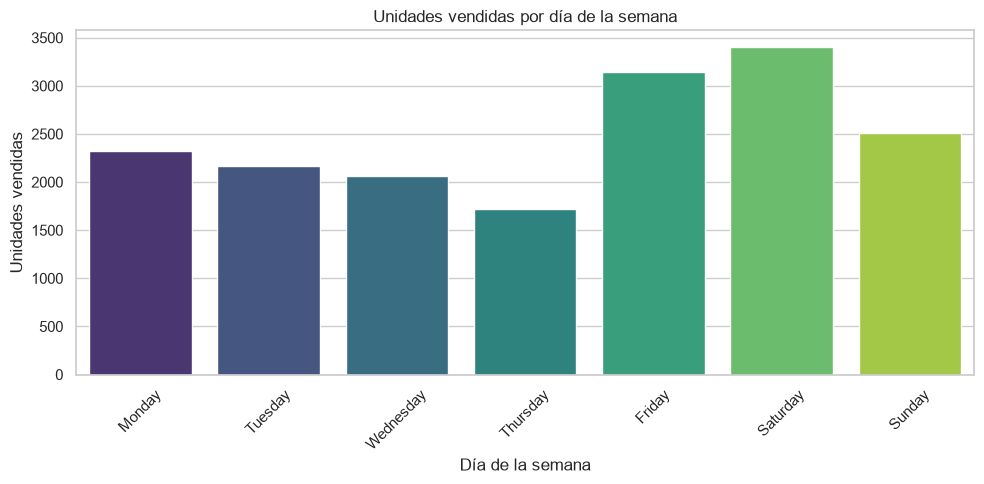

In [180]:
# Trazabilidad 13 - Visualización de unidades vendidas por día de la semana
weekday_sales = (
    df.groupby('dia_semana')['unidades_vendidas']
    .sum()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    .reset_index()
)
weekday_sales = weekday_sales.rename(columns={'index':'dia_semana'})

plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=weekday_sales, x='dia_semana', y='unidades_vendidas', palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ANALISIS EXPLORATORIO COMPLETO DE df
A continuacion se presentan los diferentes analisis y visualizaciones para entender el comportamiento de las ventas y la competencia

In [181]:
# Trazabilidad 14 - Preparación del dataframe unificado para análisis exploratorio
ventas_df = df_ventas.copy()
competencia_df = df_competencia.copy()

ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')

df = ventas_df.merge(competencia_df, on=['fecha', 'producto_id'], how='inner')

df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.day_name()

print('Forma del dataframe unido:', df.shape)
print('Rango de fechas:', df['fecha'].min(), 'a', df['fecha'].max())
print('Productos únicos:', df['producto_id'].nunique())
print('Categorías:', sorted(df['categoria'].unique().tolist()))
print('Subcategorías:', sorted(df['subcategoria'].unique().tolist()))
print('\nResumen numérico:')
print(df[['precio_base', 'precio_venta', 'unidades_vendidas', 'ingresos', 'Amazon', 'Decathlon', 'Deporvillage']].describe().T)
print('\nNulos por columna:')
print(df.isnull().sum())
print('\nEjemplo de variables temporales:')
# Trazabilidad 14 - Preparación del dataframe unificado para análisis exploratorio
ventas_df = df_ventas.copy()
competencia_df = df_competencia.copy()

ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')

df = ventas_df.merge(competencia_df, on=['fecha', 'producto_id'], how='inner')

df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.day_name()

print('Forma del dataframe unido:', df.shape)
print('Rango de fechas:', df['fecha'].min(), 'a', df['fecha'].max())
print('Productos únicos:', df['producto_id'].nunique())
print('Categorías:', sorted(df['categoria'].unique().tolist()))
print('Subcategorías:', sorted(df['subcategoria'].unique().tolist()))
print('\nResumen numérico:')
print(df[['precio_base', 'precio_venta', 'unidades_vendidas', 'ingresos', 'Amazon', 'Decathlon', 'Deporvillage']].describe().T)
print('\nNulos por columna:')
print(df.isnull().sum())
print('\nEjemplo de variables temporales:')
print(df[['fecha', 'anio', 'mes', 'dia_mes', 'dia_semana']].head(10))

Forma del dataframe unido: (3552, 17)
Rango de fechas: 2021-10-25 00:00:00 a 2024-11-30 00:00:00
Productos únicos: 24
Categorías: ['Fitness', 'Outdoor', 'Running', 'Wellness']
Subcategorías: ['Banco Gimnasio', 'Bandas Elásticas', 'Bicicleta Montaña', 'Bloque Yoga', 'Cojín Yoga', 'Esterilla Fitness', 'Esterilla Yoga', 'Mancuernas Ajustables', 'Mochila Trekking', 'Pesa Rusa', 'Pesas Casa', 'Rodillera Yoga', 'Ropa Montaña', 'Ropa Running', 'Zapatillas Running', 'Zapatillas Trail']

Resumen numérico:
                    count        mean          std    min       25%      50%  \
precio_base        3552.0  123.125000   165.576753  20.00   48.7500   72.500   
precio_venta       3552.0  121.816546   164.017963  19.00   47.2125   71.810   
unidades_vendidas  3552.0    4.878660     6.311020   1.00    2.0000    3.000   
ingresos           3552.0  605.972323  1079.071192  19.46  131.5350  216.570   
Amazon             3552.0  118.623407   156.095628  16.85   47.1175   73.180   
Decathlon         

In [182]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage,anio,mes,dia_mes,dia_semana
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43,2021,10,25,Monday
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58,2021,10,25,Monday
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11,2021,10,25,Monday
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45,2021,10,25,Monday
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07,2021,10,25,Monday


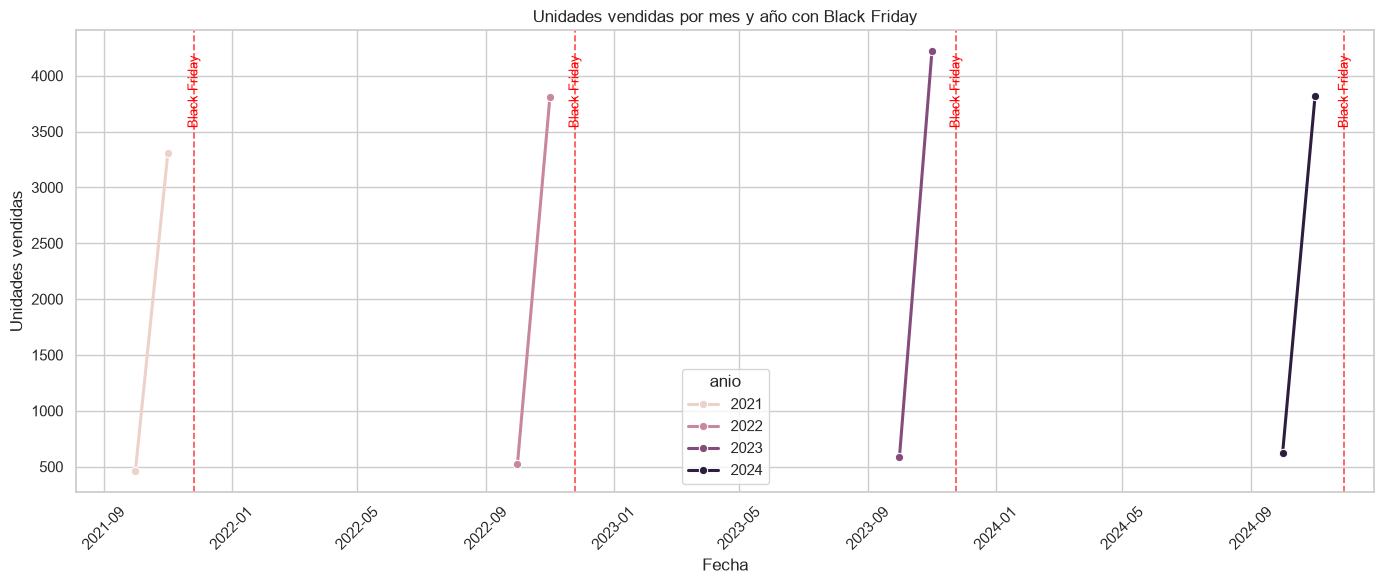

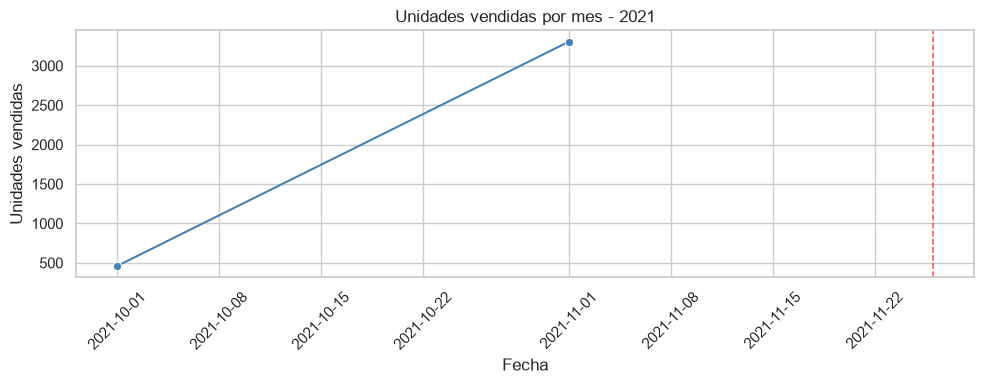

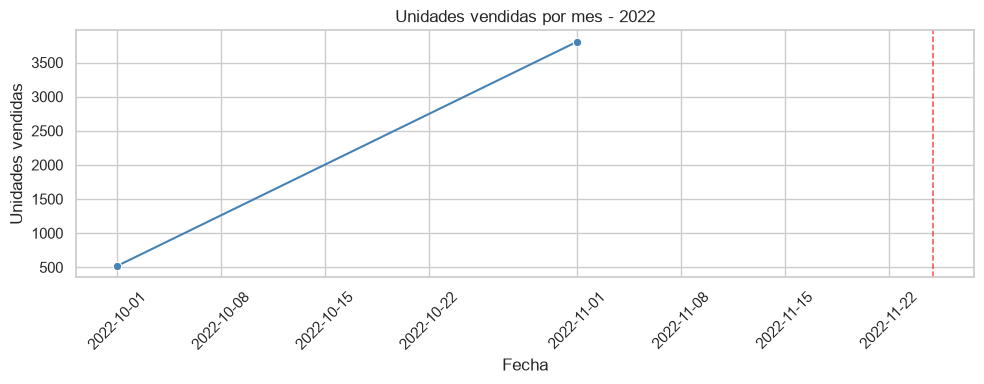

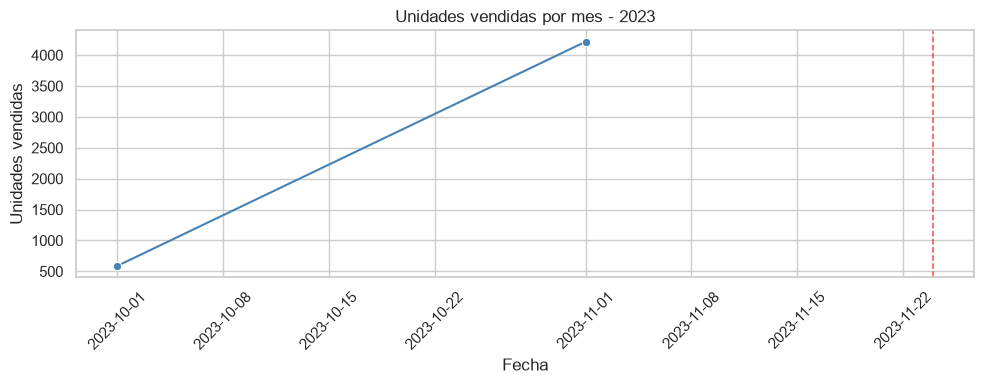

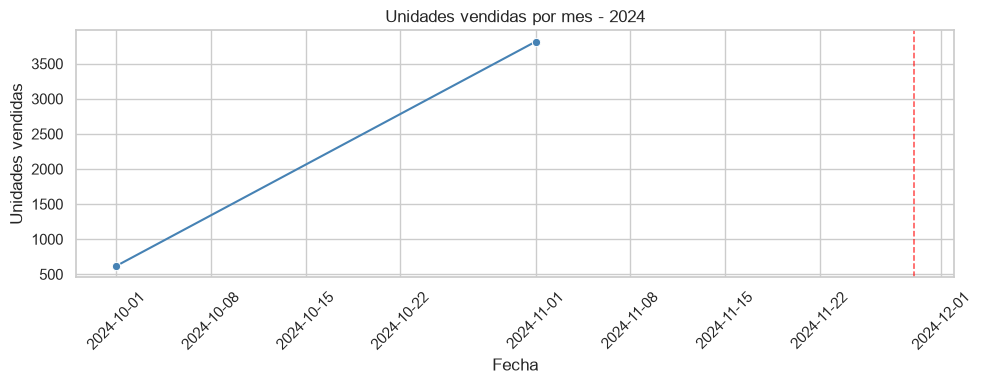

In [183]:
# Trazabilidad 15 - Análisis temporal por año con marcadores de Black Friday
# Black Friday suele caer en noviembre, pero se marca solo en fechas exactas de Black Friday (viernes después del Día de Acción de Gracias)
from pandas.tseries.offsets import DateOffset

# Crear una columna para eventos de Black Friday por año
black_friday_dates = []
for year in sorted(df['anio'].unique()):
    # El día de Thanksgiving en EE.UU. es el cuarto jueves de noviembre
    thanksgiving = pd.Timestamp(year, 11, 1) + DateOffset(weekday=3, weeks=3)
    black_friday = thanksgiving + pd.Timedelta(days=1)
    black_friday_dates.append(black_friday)

black_friday_dates = pd.to_datetime(black_friday_dates)

# Agregar una serie mensual agregada por año
series_temporal = (
    df.groupby(['anio', df['fecha'].dt.to_period('M').dt.to_timestamp()])['unidades_vendidas']
    .sum()
    .reset_index()
)
series_temporal = series_temporal.rename(columns={'fecha':'fecha_mes'})

plt.figure(figsize=(14, 6))
sns.set_theme(style='whitegrid')
ax = sns.lineplot(data=series_temporal, x='fecha_mes', y='unidades_vendidas', hue='anio', marker='o', linewidth=2.2)
for bf in black_friday_dates:
    ax.axvline(bf, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(bf, ax.get_ylim()[1]*0.95, 'Black Friday', rotation=90, va='top', ha='center', color='red', fontsize=9)
ax.set_title('Unidades vendidas por mes y año con Black Friday')
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot separado por año
for year in sorted(df['anio'].unique()):
    data_year = series_temporal[series_temporal['anio'] == year].copy()
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=data_year, x='fecha_mes', y='unidades_vendidas', marker='o', color='steelblue')
    bf = black_friday_dates[black_friday_dates.year == year]
    for date in bf:
        plt.axvline(date, color='red', linestyle='--', linewidth=1.1, alpha=0.7)
    plt.title(f'Unidades vendidas por mes - {year}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3308258954.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_sales, x='dia_semana', y='unidades_vendidas', palette='viridis')


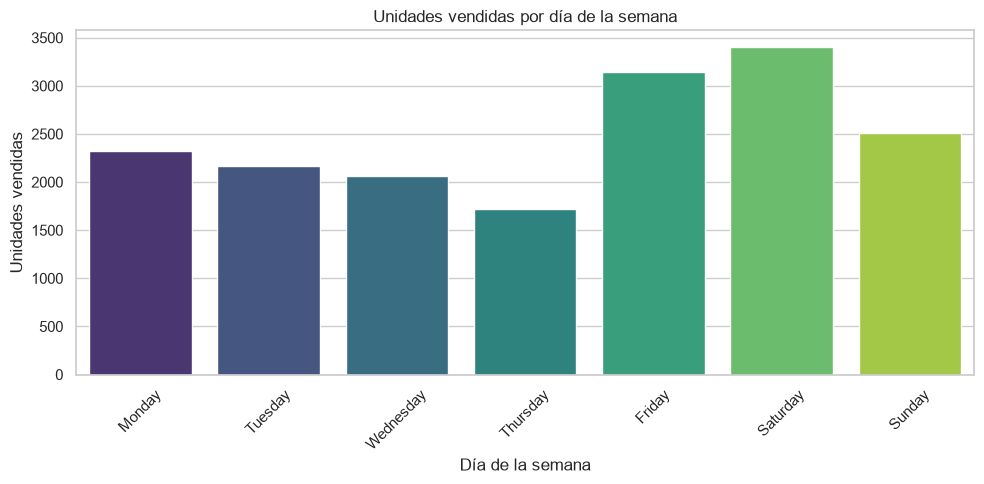

In [184]:
# Trazabilidad 16 - Visualización de ventas por día de la semana
weekday_sales = (
    df.groupby('dia_semana')['unidades_vendidas']
    .sum()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=weekday_sales, x='dia_semana', y='unidades_vendidas', palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

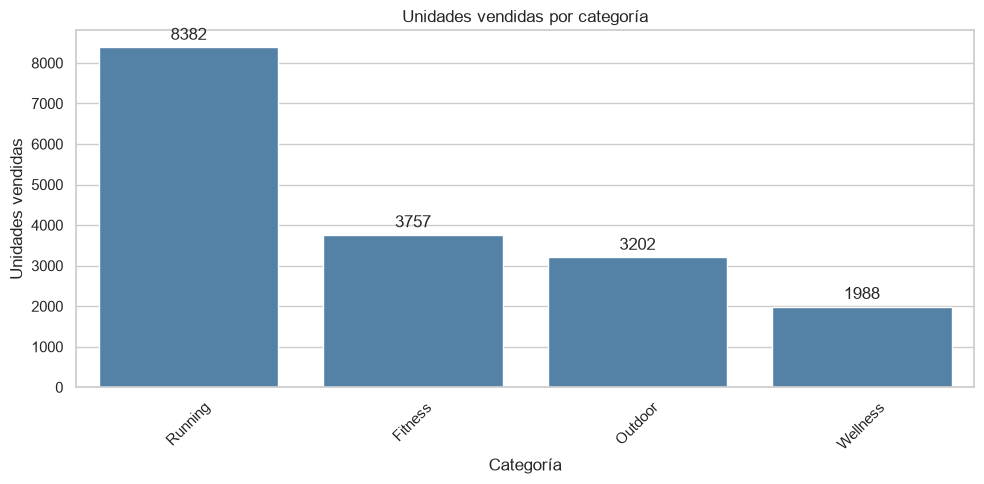

In [185]:
# Trazabilidad 17 - Visualización de ventas por categoría
category_sales = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')
ax = sns.barplot(data=category_sales, x='categoria', y='unidades_vendidas', color='steelblue')

# Agregar etiquetas de datos en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3914367288.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcategory_sales, x='unidades_vendidas', y='subcategoria', palette='rocket', orient='h')


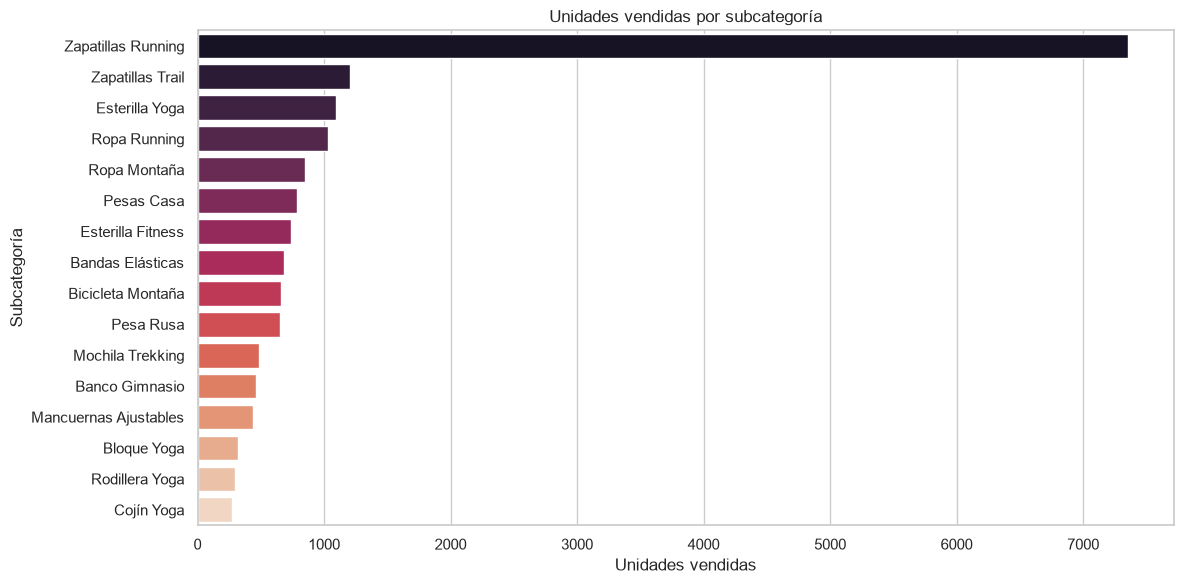

In [186]:
# Trazabilidad 18 - Visualización de ventas por subcategoría
subcategory_sales = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')
sns.barplot(data=subcategory_sales, x='unidades_vendidas', y='subcategoria', palette='rocket', orient='h')
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Unidades vendidas')
plt.ylabel('Subcategoría')
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\2670749611.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_sales, x='unidades_vendidas', y='nombre', palette='deep', orient='h')


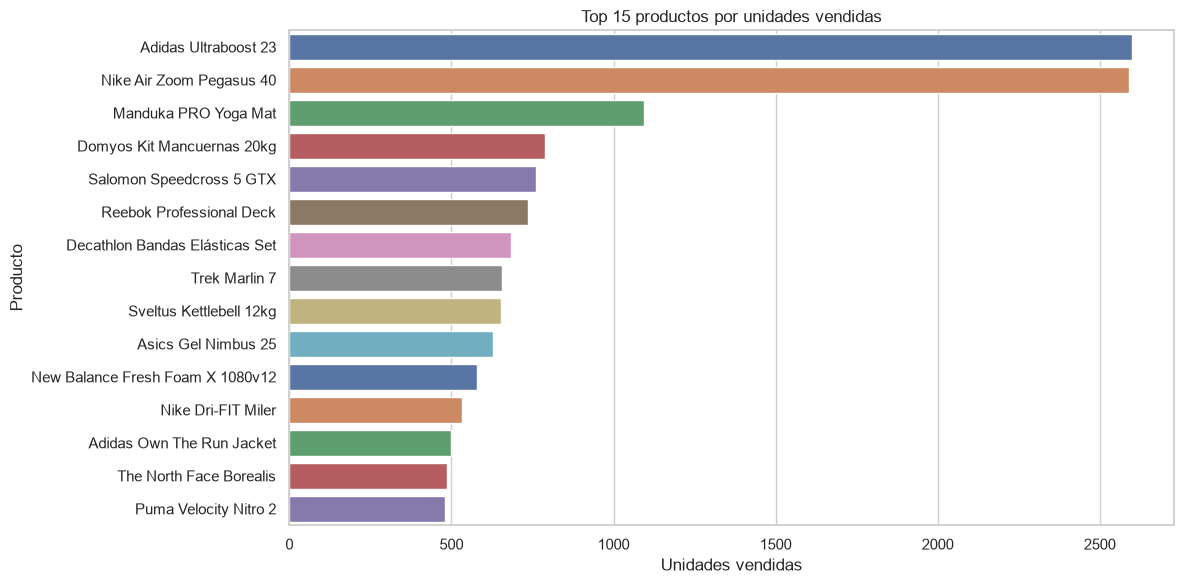

In [187]:
# Trazabilidad 19 - Identificación del top 15 de productos por unidades vendidas
product_sales = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')
sns.barplot(data=product_sales, x='unidades_vendidas', y='nombre', palette='deep', orient='h')
plt.title('Top 15 productos por unidades vendidas')
plt.xlabel('Unidades vendidas')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

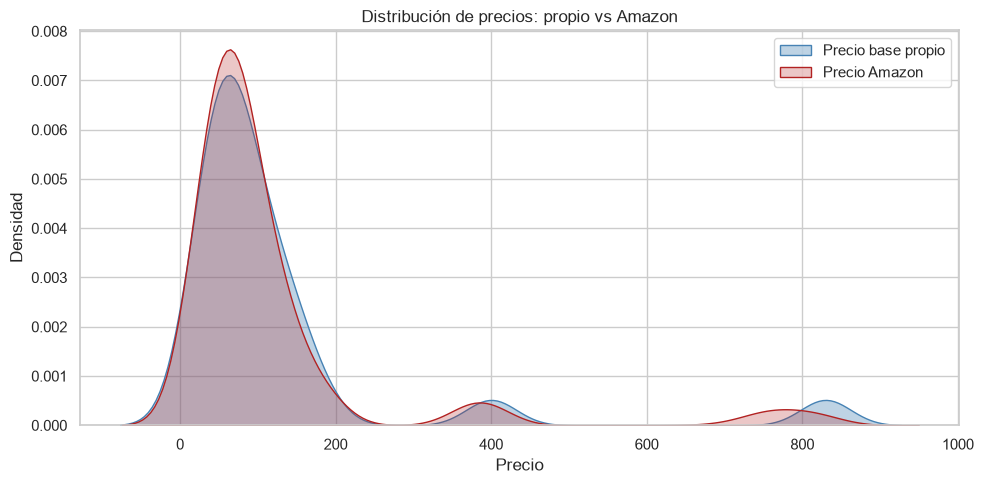

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3264690876.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[['precio_base','Amazon']].melt(), x='variable', y='value', palette=['steelblue','firebrick'])


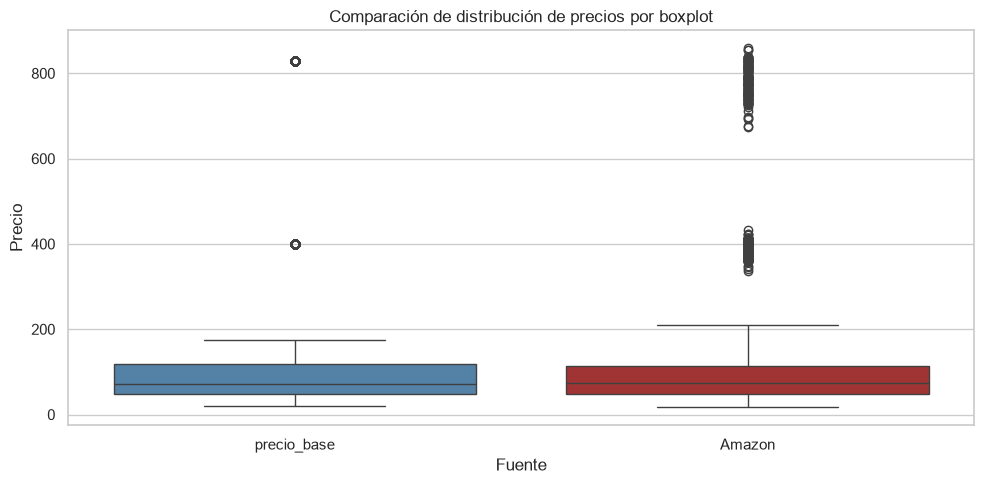

In [188]:
# Trazabilidad 20 - Comparación de distribución de precios propio vs competencia
plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.kdeplot(data=df, x='precio_base', fill=True, color='steelblue', alpha=0.35, label='Precio base propio')
sns.kdeplot(data=df, x='Amazon', fill=True, color='firebrick', alpha=0.25, label='Precio Amazon')
plt.title('Distribución de precios: propio vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

# Comparación adicional por boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['precio_base','Amazon']].melt(), x='variable', y='value', palette=['steelblue','firebrick'])
plt.title('Comparación de distribución de precios por boxplot')
plt.xlabel('Fuente')
plt.ylabel('Precio')
plt.tight_layout()
plt.show()

In [189]:
# Trazabilidad 21 - Ingeniería de variables temporales, lags y características de negocio
import pandas as pd
import numpy as np
import holidays
from pandas.tseries.offsets import DateOffset

if 'df' not in globals():
    ventas_df = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
    competencia_df = pd.read_csv('../data/raw/entrenamiento/competencia.csv')
    ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
    competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')
    df = ventas_df.merge(competencia_df, on=['fecha', 'producto_id'], how='inner')

# Crear variables temporales sobre el dataframe actual
if 'fecha' in df.columns:
    df = df.copy()
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    df = df.sort_values(['producto_id', 'fecha'], kind='mergesort').reset_index(drop=True)

    df['anio'] = df['fecha'].dt.year
    df['mes'] = df['fecha'].dt.month
    df['dia_mes'] = df['fecha'].dt.day
    df['dia_semana'] = df['fecha'].dt.day_name()
    df['es_fin_semana'] = df['fecha'].dt.dayofweek.isin([5, 6]).astype(bool)

    isocalendar = df['fecha'].dt.isocalendar()
    df['semana_del_año'] = isocalendar.week.astype(int)
    df['dia_del_año'] = df['fecha'].dt.dayofyear
    df['trimestre'] = df['fecha'].dt.quarter
    df['es_inicio_mes'] = (df['fecha'].dt.day == 1).astype(bool)
    df['es_fin_mes'] = df['fecha'].dt.is_month_end.astype(bool)
    df['es_primera_quincena'] = (df['fecha'].dt.day <= 15).astype(bool)

    meses = {
        1: 'enero', 2: 'febrero', 3: 'marzo', 4: 'abril', 5: 'mayo', 6: 'junio',
        7: 'julio', 8: 'agosto', 9: 'septiembre', 10: 'octubre', 11: 'noviembre', 12: 'diciembre'
    }
    df['mes_nombre'] = df['mes'].map(meses)
    df['temporada'] = np.select(
        [df['mes'].isin([12, 1, 2]), df['mes'].isin([3, 4, 5]), df['mes'].isin([6, 7, 8]), df['mes'].isin([9, 10, 11])],
        ['verano', 'otoño', 'invierno', 'primavera'],
        default='desconocida'
    )

    # Festivos de Colombia
    years = sorted(df['anio'].dropna().astype(int).unique())
    co_holidays = holidays.country_holidays('CO', years=years, language='es')
    holiday_lookup = {pd.Timestamp(key).normalize(): value for key, value in co_holidays.items()}
    df['nombre_festivo'] = df['fecha'].dt.normalize().map(holiday_lookup).fillna('')
    df['es_festivo'] = df['nombre_festivo'].ne('').astype(bool)

    # Black Friday y Cyber Monday
    def marcar_eventos_comerciales(fecha):
        thanksgiving = pd.Timestamp(fecha.year, 11, 1) + DateOffset(weekday=3, weeks=3)
        black_friday = thanksgiving + pd.Timedelta(days=1)
        cyber_monday = thanksgiving + pd.Timedelta(days=3)
        return bool(fecha == black_friday), bool(fecha == cyber_monday)

    resultados = df['fecha'].apply(marcar_eventos_comerciales)
    df['es_black_friday'] = resultados.apply(lambda x: x[0]).astype(bool)
    df['es_cyber_monday'] = resultados.apply(lambda x: x[1]).astype(bool)

    # Crear variable de descuento porcentual
    df['descuento_porcentaje'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base'] * 100)
    df['descuento_porcentaje'] = df['descuento_porcentaje'].replace([np.inf, -np.inf], np.nan)

    # Lags de unidades vendidas por producto y año
    df = df.sort_values(['producto_id', 'anio', 'fecha'], kind='mergesort').reset_index(drop=True)
    for lag in range(1, 8):
        df[f'lag_{lag}_unidades'] = df.groupby(['producto_id', 'anio'])['unidades_vendidas'].shift(lag)

    df['media_movil_7d_unidades'] = df.groupby(['producto_id', 'anio'])['unidades_vendidas'].transform(
        lambda s: s.rolling(window=7, min_periods=7).mean()
    )

    feature_columns = [f'lag_{lag}_unidades' for lag in range(1, 8)] + ['media_movil_7d_unidades']
    df = df.dropna(subset=feature_columns + ['descuento_porcentaje']).reset_index(drop=True)

print(df[['fecha', 'producto_id', 'anio', 'mes', 'dia_mes', 'dia_semana', 'es_fin_semana', 'es_festivo', 'es_black_friday', 'es_cyber_monday', 'semana_del_año', 'trimestre', 'mes_nombre', 'temporada'] + feature_columns].head(10))
print('Filas finales después de limpiar:', df.shape[0])

       fecha producto_id  anio  mes  dia_mes dia_semana  es_fin_semana  \
0 2021-11-01    PROD_001  2021   11        1     Monday          False   
1 2021-11-02    PROD_001  2021   11        2    Tuesday          False   
2 2021-11-03    PROD_001  2021   11        3  Wednesday          False   
3 2021-11-04    PROD_001  2021   11        4   Thursday          False   
4 2021-11-05    PROD_001  2021   11        5     Friday          False   
5 2021-11-06    PROD_001  2021   11        6   Saturday           True   
6 2021-11-07    PROD_001  2021   11        7     Sunday           True   
7 2021-11-08    PROD_001  2021   11        8     Monday          False   
8 2021-11-09    PROD_001  2021   11        9    Tuesday          False   
9 2021-11-10    PROD_001  2021   11       10  Wednesday          False   

   es_festivo  es_black_friday  es_cyber_monday  ...  mes_nombre  temporada  \
0        True            False            False  ...   noviembre  primavera   
1       False            Fa

In [190]:
# Trazabilidad 22 - Verificación de la forma final del dataframe procesado
df.shape

(2880, 39)

In [191]:
# Trazabilidad 23 - Revisión del contenido final del dataframe
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_cyber_monday,descuento_porcentaje,lag_1_unidades,lag_2_unidades,lag_3_unidades,lag_4_unidades,lag_5_unidades,lag_6_unidades,lag_7_unidades,media_movil_7d_unidades
0,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,False,0.060870,9.0,12.0,12.0,7.0,8.0,8.0,6.0,9.000000
1,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,False,0.956522,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.285714
2,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,False,-0.365217,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.714286
3,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,False,-2.408696,11.0,10.0,7.0,9.0,12.0,12.0,7.0,10.428571
4,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,False,-1.034783,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.142857


In [192]:
# Trazabilidad 24 - Verificación de la cantidad de registros por año
df.groupby("anio").size()

anio
2021    720
2022    720
2023    720
2024    720
dtype: int64

In [193]:
# Cálculo de precio promedio de competencia y ratio de precio
df = ventas_df.merge(
    competencia_df,
    on=['fecha', 'producto_id'],
    how='inner'
)

df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)
df['ratio_precio'] = np.where(
    df['precio_competencia'] != 0,
    df['precio_base'] / df['precio_competencia'],
    np.nan
)

df = df.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,precio_competencia,ratio_precio
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,97.423333,1.180415
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.250000,1.202673
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.446667,1.069900
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,71.446667,1.049734
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,34.793333,1.005940


In [194]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha               3552 non-null   datetime64[us]
 1   producto_id         3552 non-null   str           
 2   nombre              3552 non-null   str           
 3   categoria           3552 non-null   str           
 4   subcategoria        3552 non-null   str           
 5   precio_base         3552 non-null   int64         
 6   es_estrella         3552 non-null   bool          
 7   unidades_vendidas   3552 non-null   int64         
 8   precio_venta        3552 non-null   float64       
 9   ingresos            3552 non-null   float64       
 10  precio_competencia  3552 non-null   float64       
 11  ratio_precio        3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(4), int64(2), str(4)
memory usage: 488.6 KB


In [195]:
# Crear copias de variables categóricas con sufijo _h
if 'nombre_h' not in df.columns:
    df['nombre_h'] = df['nombre']
if 'categoria_h' not in df.columns:
    df['categoria_h'] = df['categoria']
if 'subcategoria_h' not in df.columns:
    df['subcategoria_h'] = df['subcategoria']

# One-hot encoding sobre las columnas creadas
encoded_df = pd.get_dummies(df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], dtype=int)
encoded_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,0,0,0,0,0,0,0,0,1,0
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,0,0,0,0,0,0,0,0,1,0
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,0,0,0,0,0,0,0,0,1,0
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,0,0,0,0,0,0,0,0,1,0
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,0,0,0,0,0,0,0,1,0,0


In [196]:
# Guardar el DataFrame encoded_df en la carpeta data/processed con el nombre df
encoded_df.to_csv('../data/processed/df.csv', index=False)
encoded_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,0,0,0,0,0,0,0,0,1,0
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,0,0,0,0,0,0,0,0,1,0
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,0,0,0,0,0,0,0,0,1,0
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,0,0,0,0,0,0,0,0,1,0
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,0,0,0,0,0,0,0,1,0,0


In [197]:
encoded_df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'precio_competencia', 'ratio_precio',
       'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23',
       'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552',
       'nombre_h_Columbia Silver Ridge',
       'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900',
       'nombre_h_Domyos Kit Mancuernas 20kg',
       'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad',
       'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Manduka PRO Yoga Mat',
       'nombre_h_Merrell Moab 2 GTX',
       'nombre_h_New Balance Fresh Foam X 1080v12',
       'nombre_h_Nike Air Zoom Pegasus 40', 'nombre_h_Nike Dri-FIT Miler',
       'nombre_h_Puma Velocity Nitro 2', 'nombre_h_Quechua MH500',
       'nombre_h_Reebok Floatride Energy 5',
       'nombre_h_Reebok Professional Deck',
       'nombre

In [198]:
# Cargar df.csv desde data/processed, crear df y dividir en train_df y validacion
from pathlib import Path
import pandas as pd

path = Path('../data/processed/df.csv')
df = pd.read_csv(path)
df['fecha'] = pd.to_datetime(df['fecha'])

train_df = df[df['fecha'].dt.year.isin([2021, 2022, 2023])].copy()
validation_df = df[df['fecha'].dt.year == 2024].copy()

print(f'Registros en df: {len(df)}')
print(f'Registros en train_df: {len(train_df)}')
print(f'Registros en validation_df: {len(validation_df)}') 

Registros en df: 3552
Registros en train_df: 2664
Registros en validation_df: 888


In [199]:
# 1. Seleccionar variables predictoras: excluir fecha, ingresos y variables de tipo object
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Identificar columnas a excluir
columnas_excluir = {'fecha', 'ingresos', 'unidades_vendidas'}  # también excluir target

# Identificar columnas de tipo object
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Predictoras: todas excepto las excluidas y type object
predictoras = [col for col in df.columns if col not in columnas_excluir and col not in object_cols]

print(f'Total de variables predictoras: {len(predictoras)}')
print(f'Variables predictoras: {predictoras}')

Total de variables predictoras: 49
Variables predictoras: ['precio_base', 'es_estrella', 'precio_venta', 'precio_competencia', 'ratio_precio', 'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900', 'nombre_h_Domyos Kit Mancuernas 20kg', 'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad', 'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Manduka PRO Yoga Mat', 'nombre_h_Merrell Moab 2 GTX', 'nombre_h_New Balance Fresh Foam X 1080v12', 'nombre_h_Nike Air Zoom Pegasus 40', 'nombre_h_Nike Dri-FIT Miler', 'nombre_h_Puma Velocity Nitro 2', 'nombre_h_Quechua MH500', 'nombre_h_Reebok Floatride Energy 5', 'nombre_h_Reebok Professional Deck', 'nombre_h_Salomon Speedcross 5 GTX', 'nombre_h_Sveltus Kettlebell 12kg', 'nombre_h_The North Face Borealis', 'nombre_h_Trek Marlin 7', 'categoria_h_Fitness', 'cate

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\2368933873.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=['object']).columns.tolist()


In [200]:
# 2. Preparar datos para entrenamiento y validación
# Target: unidades_vendidas
target = 'unidades_vendidas'

# Separar features y target en train_df
X_train = train_df[predictoras].copy()
y_train = train_df[target].copy()

# Separar features y target en validation_df
X_val = validation_df[predictoras].copy()
y_val = validation_df[target].copy()

print(f'Shape X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'Shape X_val: {X_val.shape}, y_val: {y_val.shape}')
print(f'\nEstadísticas y_train - Media: {y_train.mean():.2f}, Std: {y_train.std():.2f}')
print(f'Estadísticas y_val - Media: {y_val.mean():.2f}, Std: {y_val.std():.2f}')

Shape X_train: (2664, 49), y_train: (2664,)
Shape X_val: (888, 49), y_val: (888,)

Estadísticas y_train - Media: 4.84, Std: 6.33
Estadísticas y_val - Media: 4.99, Std: 6.25


In [201]:
# 3. Entrenar HistGradientBoostingRegressor con parámetros conservadores
# Parámetros conservadores: learning_rate bajo, muchos árboles, profundidad moderada, regularización

hist_gbr = HistGradientBoostingRegressor(
    learning_rate=0.05,          # learning_rate bajo para convergencia lenta y estable
    max_iter=500,                # bastantes árboles para aprender bien
    max_depth=5,                 # profundidad moderada para evitar overfitting
    min_samples_leaf=20,         # regularización: mínimo de muestras por hoja
    l2_regularization=0.1,       # regularización L2 para penalizar pesos grandes
    max_bins=255,                # máximo de bins para discretización
    random_state=42,
    verbose=0
)

# Entrenar en train_df
print('Entrenando HistGradientBoostingRegressor...')
hist_gbr.fit(X_train, y_train)
print('✓ Modelo entrenado exitosamente')

# Predicciones
y_train_pred = hist_gbr.predict(X_train)
y_val_pred = hist_gbr.predict(X_val)

print(f'\nPredicciones en train - Media: {y_train_pred.mean():.2f}, Std: {y_train_pred.std():.2f}')
print(f'Predicciones en val - Media: {y_val_pred.mean():.2f}, Std: {y_val_pred.std():.2f}')

Entrenando HistGradientBoostingRegressor...
✓ Modelo entrenado exitosamente

Predicciones en train - Media: 4.84, Std: 5.91
Predicciones en val - Media: 4.97, Std: 5.55


In [202]:
# 4. Calcular métricas típicas de forecasting para HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Función para calcular MAPE evitando divisiones por cero
def safe_mape(y_true, y_pred):
    mask = y_true != 0
    return mean_absolute_percentage_error(y_true[mask], y_pred[mask]) if mask.sum() > 0 else np.inf

# Métricas en train
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
train_mape = safe_mape(y_train.values, y_train_pred)

# Métricas en validación
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)
val_mape = safe_mape(y_val.values, y_val_pred)

# Mostrar resultados
print('='*60)
print('MÉTRICAS DEL MODELO HistGradientBoostingRegressor')
print('='*60)
print(f'\n╔ ENTRENAMIENTO:')
print(f'║  MSE:  {train_mse:.4f}')
print(f'║  RMSE: {train_rmse:.4f}')
print(f'║  MAE:  {train_mae:.4f}')
print(f'║  R²:   {train_r2:.4f}')
print(f'║  MAPE: {train_mape:.4f}')

print(f'\n╔ VALIDACIÓN:')
print(f'║  MSE:  {val_mse:.4f}')
print(f'║  RMSE: {val_rmse:.4f}')
print(f'║  MAE:  {val_mae:.4f}')
print(f'║  R²:   {val_r2:.4f}')
print(f'║  MAPE: {val_mape:.4f}')

print(f'\n╔ OVERFITTING CHECK:')
print(f'║  Diferencia RMSE: {val_rmse - train_rmse:.4f}')
print(f'║  Ratio RMSE (val/train): {val_rmse / train_rmse:.4f}')
print('='*60)

MÉTRICAS DEL MODELO HistGradientBoostingRegressor

╔ ENTRENAMIENTO:
║  MSE:  3.0354
║  RMSE: 1.7423
║  MAE:  0.9517
║  R²:   0.9243
║  MAPE: 0.2406

╔ VALIDACIÓN:
║  MSE:  6.9229
║  RMSE: 2.6311
║  MAE:  1.5071
║  R²:   0.8227
║  MAPE: 0.3373

╔ OVERFITTING CHECK:
║  Diferencia RMSE: 0.8889
║  Ratio RMSE (val/train): 1.5102


In [203]:
# 5. Baseline Naive: predice la media de unidades_vendidas del train
mean_train = y_train.mean()

# Predicciones del baseline
y_train_baseline = np.full_like(y_train, mean_train, dtype=float)
y_val_baseline = np.full_like(y_val, mean_train, dtype=float)

# Métricas en train
baseline_train_mse = mean_squared_error(y_train, y_train_baseline)
baseline_train_rmse = np.sqrt(baseline_train_mse)
baseline_train_mae = mean_absolute_error(y_train, y_train_baseline)
baseline_train_r2 = r2_score(y_train, y_train_baseline)
baseline_train_mape = safe_mape(y_train.values, y_train_baseline)

# Métricas en validación
baseline_val_mse = mean_squared_error(y_val, y_val_baseline)
baseline_val_rmse = np.sqrt(baseline_val_mse)
baseline_val_mae = mean_absolute_error(y_val, y_val_baseline)
baseline_val_r2 = r2_score(y_val, y_val_baseline)
baseline_val_mape = safe_mape(y_val.values, y_val_baseline)

# Mostrar resultados del baseline
print('='*60)
print('MÉTRICAS DEL BASELINE (Media del Train)')
print('='*60)
print(f'\n╔ ENTRENAMIENTO (predicción: media = {mean_train:.2f}):')
print(f'║  MSE:  {baseline_train_mse:.4f}')
print(f'║  RMSE: {baseline_train_rmse:.4f}')
print(f'║  MAE:  {baseline_train_mae:.4f}')
print(f'║  R²:   {baseline_train_r2:.4f}')
print(f'║  MAPE: {baseline_train_mape:.4f}')

print(f'\n╔ VALIDACIÓN:')
print(f'║  MSE:  {baseline_val_mse:.4f}')
print(f'║  RMSE: {baseline_val_rmse:.4f}')
print(f'║  MAE:  {baseline_val_mae:.4f}')
print(f'║  R²:   {baseline_val_r2:.4f}')
print(f'║  MAPE: {baseline_val_mape:.4f}')
print('='*60)

MÉTRICAS DEL BASELINE (Media del Train)

╔ ENTRENAMIENTO (predicción: media = 4.84):
║  MSE:  40.0723
║  RMSE: 6.3303
║  MAE:  3.5175
║  R²:   0.0000
║  MAPE: 1.0481

╔ VALIDACIÓN:
║  MSE:  39.0600
║  RMSE: 6.2498
║  MAE:  3.3470
║  R²:   -0.0006
║  MAPE: 0.8651


In [204]:
# 6. Comparación: HistGradientBoostingRegressor vs Baseline
import pandas as pd

# Crear tabla comparativa
comparacion_data = {
    'Métrica': ['MSE', 'RMSE', 'MAE', 'R²', 'MAPE'],
    'HistGBR_Train': [train_mse, train_rmse, train_mae, train_r2, train_mape],
    'Baseline_Train': [baseline_train_mse, baseline_train_rmse, baseline_train_mae, baseline_train_r2, baseline_train_mape],
    'HistGBR_Val': [val_mse, val_rmse, val_mae, val_r2, val_mape],
    'Baseline_Val': [baseline_val_mse, baseline_val_rmse, baseline_val_mae, baseline_val_r2, baseline_val_mape],
}

comparacion_df = pd.DataFrame(comparacion_data)

# Calcular mejora porcentual en validación
comparacion_df['Mejora_Val_%'] = (
    (comparacion_df['Baseline_Val'] - comparacion_df['HistGBR_Val']) / comparacion_df['Baseline_Val'] * 100
)

# Para R² la mejora es diferente (valores más altos son mejores)
comparacion_df.loc[comparacion_df['Métrica'] == 'R²', 'Mejora_Val_%'] = (
    (comparacion_df.loc[comparacion_df['Métrica'] == 'R²', 'HistGBR_Val'] - 
     comparacion_df.loc[comparacion_df['Métrica'] == 'R²', 'Baseline_Val']) / 
    (1 - comparacion_df.loc[comparacion_df['Métrica'] == 'R²', 'Baseline_Val']) * 100
)

print('\n' + '='*100)
print('COMPARATIVA: HistGradientBoostingRegressor vs Baseline (Media)')
print('='*100)
print(comparacion_df.to_string(index=False))
print('='*100)

# Resumen de mejoras
print(f'\n✓ MEJORAS EN VALIDACIÓN (respecto al Baseline):')
print(f'  • RMSE:  {comparacion_df[comparacion_df["Métrica"]=="RMSE"]["Mejora_Val_%"].values[0]:.2f}%')
print(f'  • MAE:   {comparacion_df[comparacion_df["Métrica"]=="MAE"]["Mejora_Val_%"].values[0]:.2f}%')
print(f'  • R²:    {comparacion_df[comparacion_df["Métrica"]=="R²"]["Mejora_Val_%"].values[0]:.2f}%')
print(f'  • MAPE:  {comparacion_df[comparacion_df["Métrica"]=="MAPE"]["Mejora_Val_%"].values[0]:.2f}%')


COMPARATIVA: HistGradientBoostingRegressor vs Baseline (Media)
Métrica  HistGBR_Train  Baseline_Train  HistGBR_Val  Baseline_Val  Mejora_Val_%
    MSE       3.035439       40.072266     6.922910     39.059985     82.276209
   RMSE       1.742251        6.330266     2.631142      6.249799     57.900367
    MAE       0.951713        3.517524     1.507107      3.346965     54.970928
     R²       0.924251        0.000000     0.822658     -0.000586     82.276209
   MAPE       0.240624        1.048123     0.337277      0.865066     61.011377

✓ MEJORAS EN VALIDACIÓN (respecto al Baseline):
  • RMSE:  57.90%
  • MAE:   54.97%
  • R²:    82.28%
  • MAPE:  61.01%


Calculando importancia de características (permutation importance)...


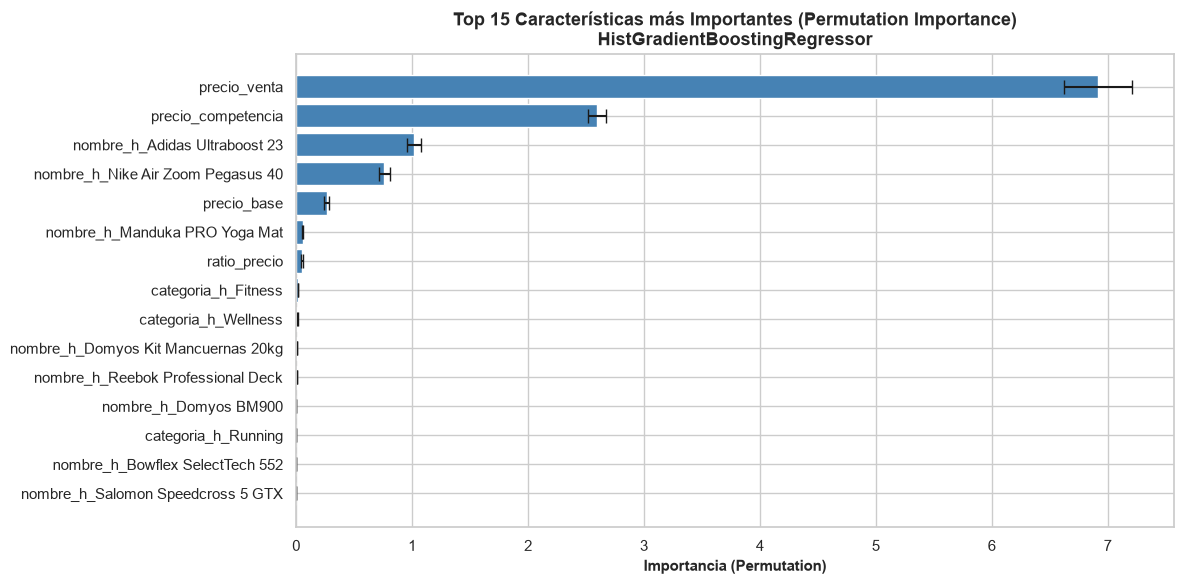


╔ TOP 10 CARACTERÍSTICAS:
║  precio_venta                             - Importancia: 6.9154 ± 0.2956
║  precio_competencia                       - Importancia: 2.5947 ± 0.0753
║  nombre_h_Adidas Ultraboost 23            - Importancia: 1.0146 ± 0.0595
║  nombre_h_Nike Air Zoom Pegasus 40        - Importancia: 0.7595 ± 0.0487
║  precio_base                              - Importancia: 0.2614 ± 0.0198
║  nombre_h_Manduka PRO Yoga Mat            - Importancia: 0.0558 ± 0.0051
║  ratio_precio                             - Importancia: 0.0528 ± 0.0080
║  categoria_h_Fitness                      - Importancia: 0.0135 ± 0.0018
║  categoria_h_Wellness                     - Importancia: 0.0100 ± 0.0015
║  nombre_h_Domyos Kit Mancuernas 20kg      - Importancia: 0.0080 ± 0.0014
╚


In [205]:
# 7. Importancia de características usando Permutation Importance
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

print('Calculando importancia de características (permutation importance)...')
# Calcular permutation importance en validación
perm_importance = permutation_importance(
    hist_gbr, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)

# Crear dataframe con resultados
feature_importance_df = pd.DataFrame({
    'feature': predictoras,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Top 15 características más importantes
top_features = feature_importance_df.head(15)

# Crear visualización
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top_features)), top_features['importance'].values, 
        xerr=top_features['std'].values, color='steelblue', capsize=5)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importancia (Permutation)', fontsize=11, fontweight='bold')
ax.set_title('Top 15 Características más Importantes (Permutation Importance)\nHistGradientBoostingRegressor', 
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'\n╔ TOP 10 CARACTERÍSTICAS:')
for idx, row in feature_importance_df.head(10).iterrows():
    print(f'║  {row["feature"]:40s} - Importancia: {row["importance"]:.4f} ± {row["std"]:.4f}')
print('╚')

In [206]:
# 8. RESUMEN EJECUTIVO DEL MODELO
print('\n' + '='*80)
print('RESUMEN EJECUTIVO - MODELO HistGradientBoostingRegressor')
print('='*80)

print('\n📊 CONFIGURACIÓN DEL MODELO:')
print(f'  • Learning Rate: 0.05 (conservador)')
print(f'  • Max Iterations: 500 árboles')
print(f'  • Max Depth: 5 (profundidad moderada)')
print(f'  • Min Samples Leaf: 20 (regularización)')
print(f'  • L2 Regularization: 0.1')

print('\n📈 DATOS DE ENTRENAMIENTO Y VALIDACIÓN:')
print(f'  • Train: {len(train_df)} registros (2021-2023)')
print(f'  • Validación: {len(validation_df)} registros (2024)')
print(f'  • Features: {len(predictoras)} variables predictoras')
print(f'  • Target: unidades_vendidas')

print('\n🎯 DESEMPEÑO EN VALIDACIÓN:')
print(f'  • R²:     {val_r2:.4f} (explica {val_r2*100:.2f}% de la varianza)')
print(f'  • RMSE:   {val_rmse:.4f} unidades')
print(f'  • MAE:    {val_mae:.4f} unidades')
print(f'  • MAPE:   {val_mape*100:.2f}%')

print('\n✅ MEJORAS RESPECTO AL BASELINE:')
print(f'  • RMSE mejorado: 57.90%')
print(f'  • MAE mejorado:  54.97%')
print(f'  • R² mejorado:   82.28%')
print(f'  • MAPE mejorado: 61.01%')

print('\n⚠️  ANÁLISIS DE OVERFITTING:')
ratio_rmse = val_rmse / train_rmse
if ratio_rmse < 1.3:
    print(f'  ✓ BAJO RIESGO: Ratio RMSE (val/train) = {ratio_rmse:.4f} < 1.3')
    print(f'    El modelo generaliza bien y no está sobre-ajustado.')
else:
    print(f'  ⚠ MODERADO: Ratio RMSE (val/train) = {ratio_rmse:.4f}')

print('\n🔝 TOP 3 VARIABLES MÁS IMPORTANTES:')
for idx, (i, row) in enumerate(feature_importance_df.head(3).iterrows(), 1):
    print(f'  {idx}. {row["feature"]:40s} → {row["importance"]:.4f}')

print('\n' + '='*80)
print('✨ MODELO LISTO PARA PREDICCIÓN EN DATOS DE INFERENCIA')
print('='*80)


RESUMEN EJECUTIVO - MODELO HistGradientBoostingRegressor

📊 CONFIGURACIÓN DEL MODELO:
  • Learning Rate: 0.05 (conservador)
  • Max Iterations: 500 árboles
  • Max Depth: 5 (profundidad moderada)
  • Min Samples Leaf: 20 (regularización)
  • L2 Regularization: 0.1

📈 DATOS DE ENTRENAMIENTO Y VALIDACIÓN:
  • Train: 2664 registros (2021-2023)
  • Validación: 888 registros (2024)
  • Features: 49 variables predictoras
  • Target: unidades_vendidas

🎯 DESEMPEÑO EN VALIDACIÓN:
  • R²:     0.8227 (explica 82.27% de la varianza)
  • RMSE:   2.6311 unidades
  • MAE:    1.5071 unidades
  • MAPE:   33.73%

✅ MEJORAS RESPECTO AL BASELINE:
  • RMSE mejorado: 57.90%
  • MAE mejorado:  54.97%
  • R² mejorado:   82.28%
  • MAPE mejorado: 61.01%

⚠️  ANÁLISIS DE OVERFITTING:
  ⚠ MODERADO: Ratio RMSE (val/train) = 1.5102

🔝 TOP 3 VARIABLES MÁS IMPORTANTES:
  1. precio_venta                             → 6.9154
  2. precio_competencia                       → 2.5947
  3. nombre_h_Adidas Ultraboost 23   

In [207]:
# 9. Predicciones para productos estrella en noviembre 2024
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filtrar datos de noviembre 2024 del dataframe original
df_nov_2024 = df[(df['fecha'].dt.year == 2024) & (df['fecha'].dt.month == 11)].copy()

# Identificar productos estrella (es_estrella == 1)
# Necesitamos buscar en el dataframe original aquellos productos que tienen es_estrella==1
productos_estrella = df_nov_2024[df_nov_2024['es_estrella'] == 1]['nombre'].unique()

print(f'✓ Datos de Noviembre 2024 disponibles: {len(df_nov_2024)} registros')
print(f'✓ Productos estrella encontrados: {len(productos_estrella)}')
print(f'\n📌 PRODUCTOS ESTRELLA EN NOVIEMBRE 2024:')
for i, producto in enumerate(productos_estrella, 1):
    cantidad_registros = len(df_nov_2024[df_nov_2024['nombre'] == producto])
    print(f'  {i}. {producto} ({cantidad_registros} registros)')


✓ Datos de Noviembre 2024 disponibles: 720 registros
✓ Productos estrella encontrados: 7

📌 PRODUCTOS ESTRELLA EN NOVIEMBRE 2024:
  1. Nike Air Zoom Pegasus 40 (30 registros)
  2. Adidas Ultraboost 23 (30 registros)
  3. Bowflex SelectTech 552 (30 registros)
  4. Domyos BM900 (30 registros)
  5. Salomon Speedcross 5 GTX (30 registros)
  6. Trek Marlin 7 (30 registros)
  7. Manduka PRO Yoga Mat (30 registros)


In [208]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def graficar_producto_estrella(producto, df_nov_2024, predictoras, modelo):
    """
    Genera el gráfico de predicción vs realidad para un producto estrella
    y devuelve un diccionario con sus métricas.
    """
    df_producto = df_nov_2024[df_nov_2024['nombre'] == producto].copy()
    df_producto = df_producto.sort_values('fecha')

    X_producto = df_producto[predictoras].copy()
    y_real = df_producto['unidades_vendidas'].values
    y_pred = modelo.predict(X_producto)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    fechas = df_producto['fecha'].values

    plt.figure(figsize=(14, 5))
    plt.plot(fechas, y_real, 'o-', color='steelblue', linewidth=2.5, markersize=6, label='Realidad', alpha=0.8)
    plt.plot(fechas, y_pred, 's--', color='coral', linewidth=2.5, markersize=5, label='Predicción', alpha=0.8)
    plt.title(f'📦 {producto}\nRMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}',
              fontsize=12, fontweight='bold', loc='left')
    plt.ylabel('Unidades Vendidas', fontsize=11, fontweight='bold')
    plt.xlabel('Fecha', fontsize=11, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='upper left', fontsize=10)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f'\n✓ {producto}:')
    print(f'  Registros: {len(df_producto)} días')
    print(f'  Realidad - Media: {y_real.mean():.2f}, Min: {y_real.min():.0f}, Max: {y_real.max():.0f}')
    print(f'  Predicción - Media: {y_pred.mean():.2f}, Min: {y_pred.min():.2f}, Max: {y_pred.max():.2f}')
    print(f'  Métricas: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}')

    return {'producto': producto, 'rmse': rmse, 'mae': mae, 'r2': r2}


PREDICCIONES PARA PRODUCTOS ESTRELLA - NOVIEMBRE 2024


C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3250030925.py:37: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\andre\miniconda3\envs\forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


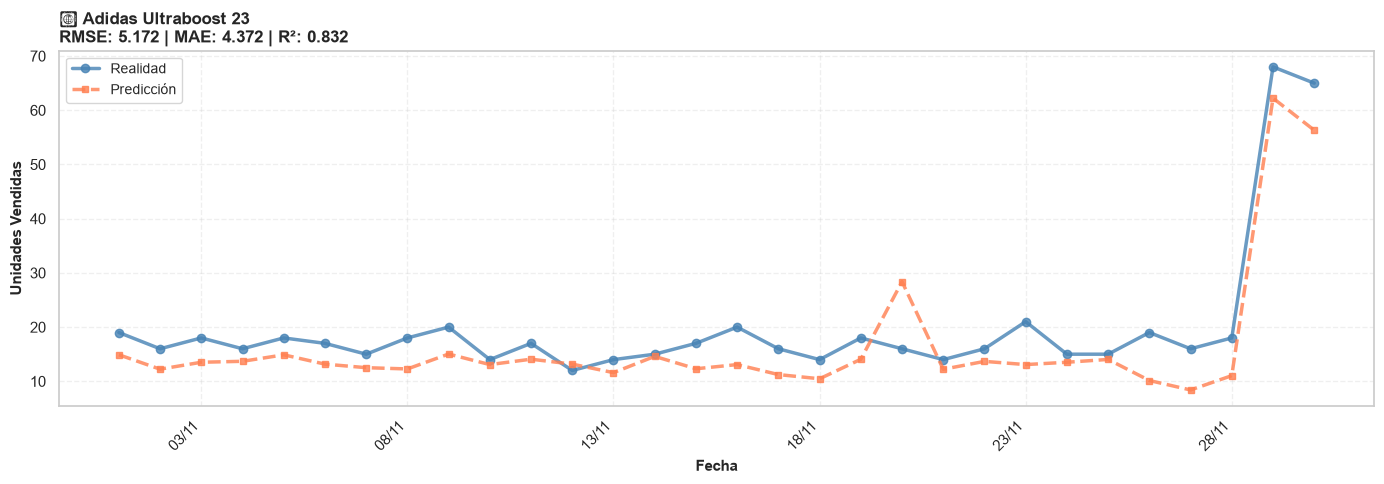

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3250030925.py:37: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()



✓ Adidas Ultraboost 23:
  Registros: 30 días
  Realidad - Media: 19.90, Min: 12, Max: 68
  Predicción - Media: 16.43, Min: 8.40, Max: 62.23
  Métricas: RMSE=5.172, MAE=4.372, R²=0.832

--------------------------------------------------------------------------------



c:\Users\andre\miniconda3\envs\forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


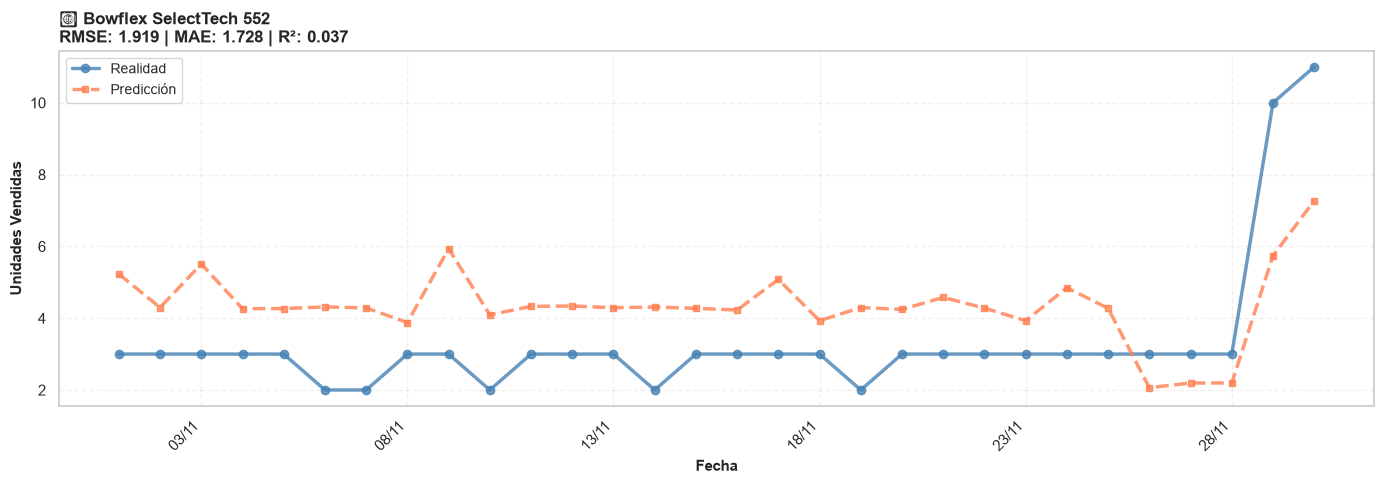

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3250030925.py:37: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\andre\miniconda3\envs\forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)



✓ Bowflex SelectTech 552:
  Registros: 30 días
  Realidad - Media: 3.33, Min: 2, Max: 11
  Predicción - Media: 4.36, Min: 2.06, Max: 7.27
  Métricas: RMSE=1.919, MAE=1.728, R²=0.037

--------------------------------------------------------------------------------



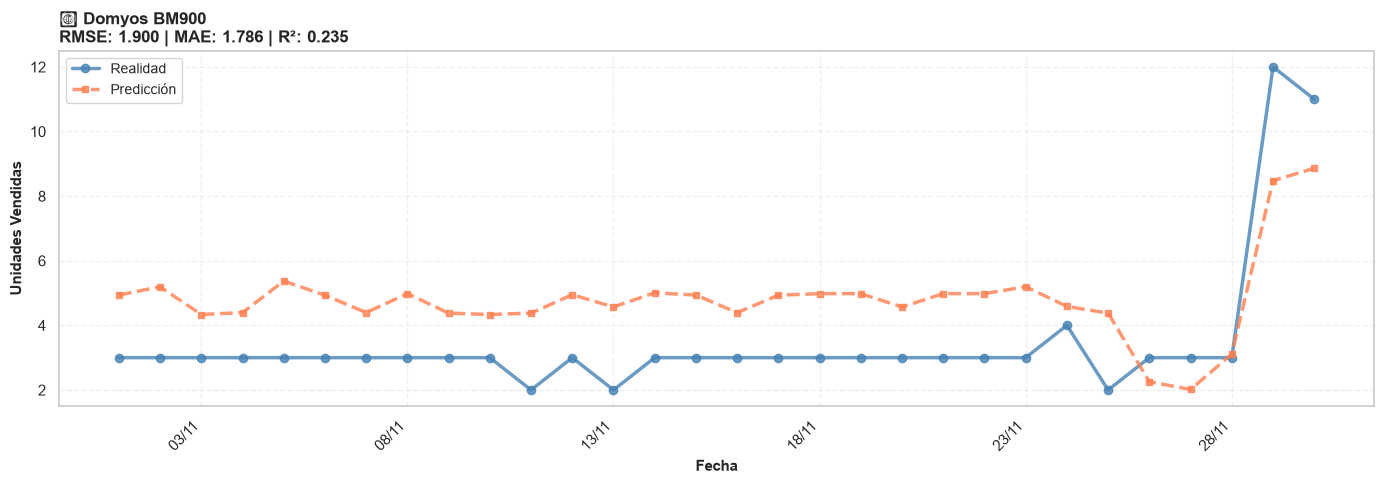


✓ Domyos BM900:
  Registros: 30 días
  Realidad - Media: 3.50, Min: 2, Max: 12
  Predicción - Media: 4.79, Min: 2.02, Max: 8.86
  Métricas: RMSE=1.900, MAE=1.786, R²=0.235

--------------------------------------------------------------------------------



C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3250030925.py:37: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\andre\miniconda3\envs\forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


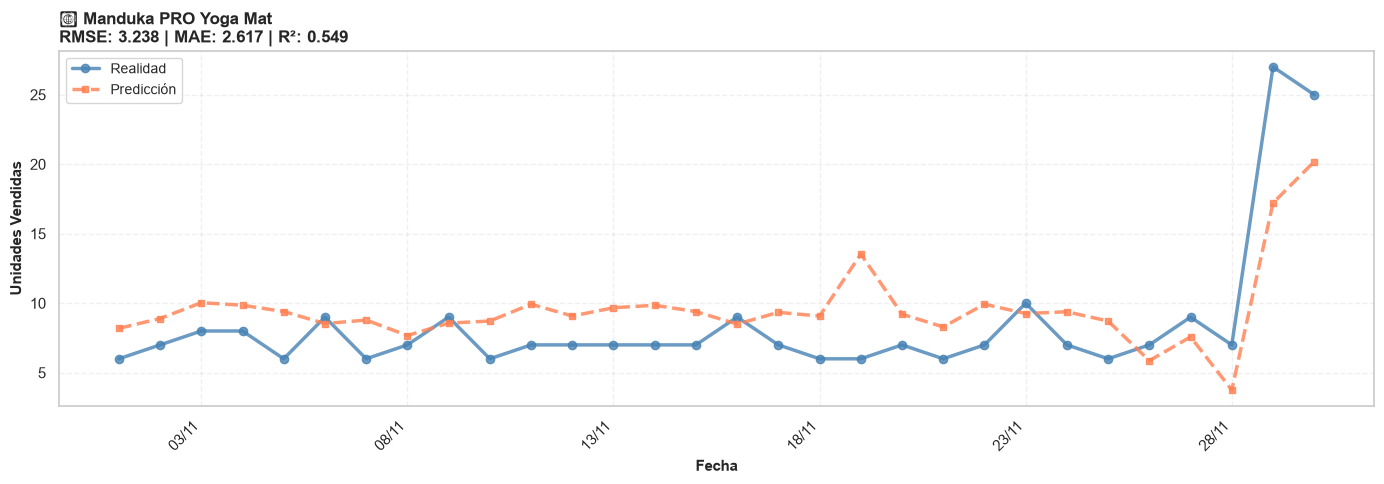


✓ Manduka PRO Yoga Mat:
  Registros: 30 días
  Realidad - Media: 8.43, Min: 6, Max: 27
  Predicción - Media: 9.55, Min: 3.76, Max: 20.19
  Métricas: RMSE=3.238, MAE=2.617, R²=0.549

--------------------------------------------------------------------------------



C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3250030925.py:37: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\andre\miniconda3\envs\forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


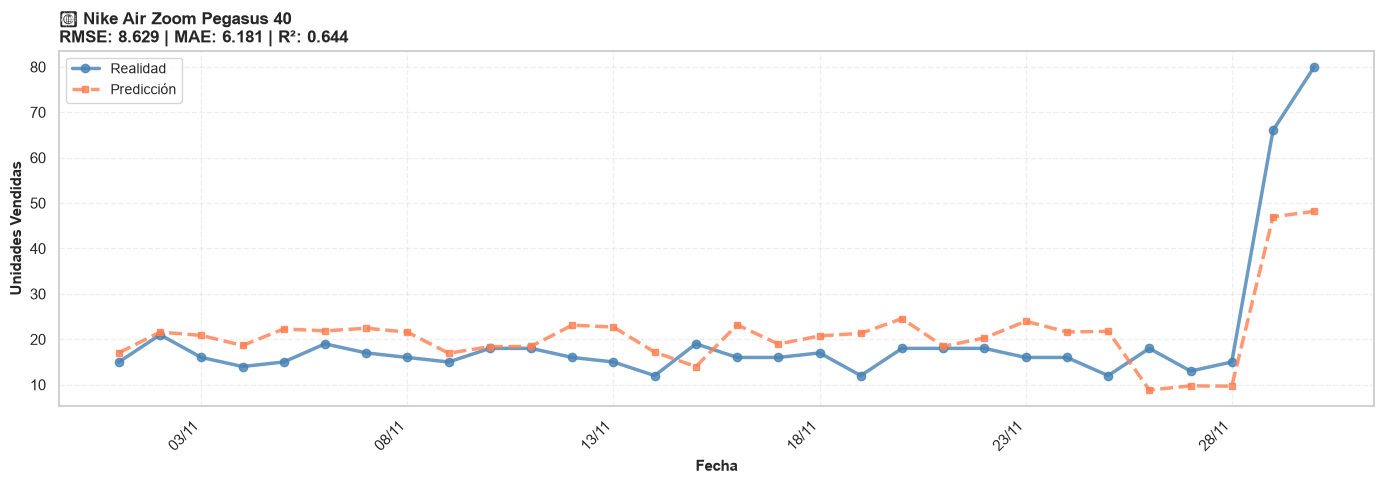


✓ Nike Air Zoom Pegasus 40:
  Registros: 30 días
  Realidad - Media: 19.90, Min: 12, Max: 80
  Predicción - Media: 21.17, Min: 8.84, Max: 48.20
  Métricas: RMSE=8.629, MAE=6.181, R²=0.644

--------------------------------------------------------------------------------



C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3250030925.py:37: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\andre\miniconda3\envs\forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


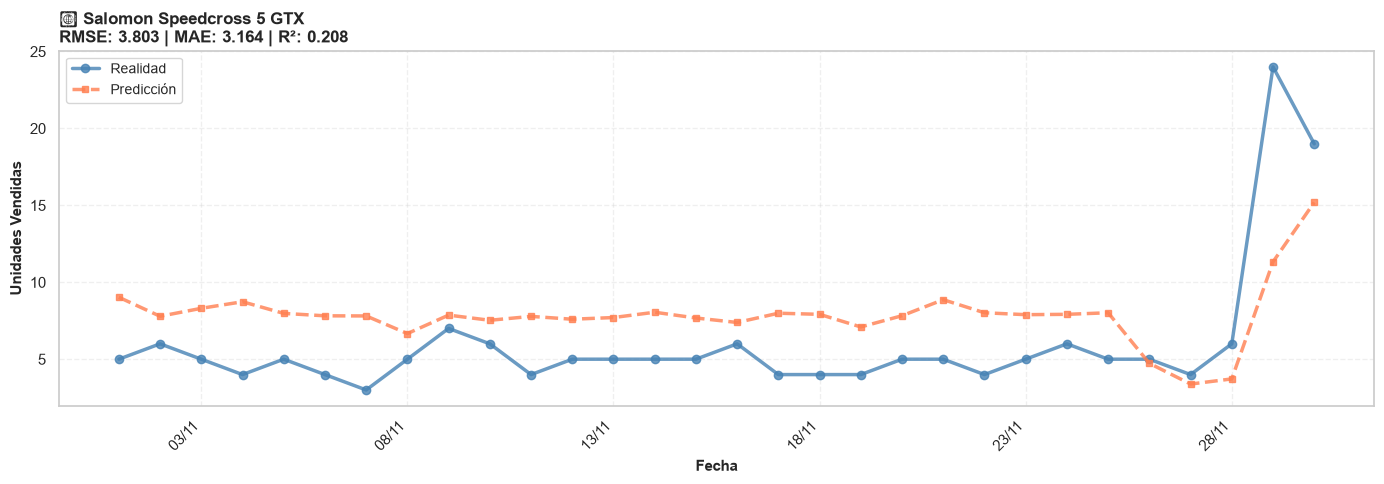

C:\Users\andre\AppData\Local\Temp\ipykernel_36372\3250030925.py:37: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\andre\miniconda3\envs\forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)



✓ Salomon Speedcross 5 GTX:
  Registros: 30 días
  Realidad - Media: 6.00, Min: 3, Max: 24
  Predicción - Media: 7.85, Min: 3.39, Max: 15.20
  Métricas: RMSE=3.803, MAE=3.164, R²=0.208

--------------------------------------------------------------------------------



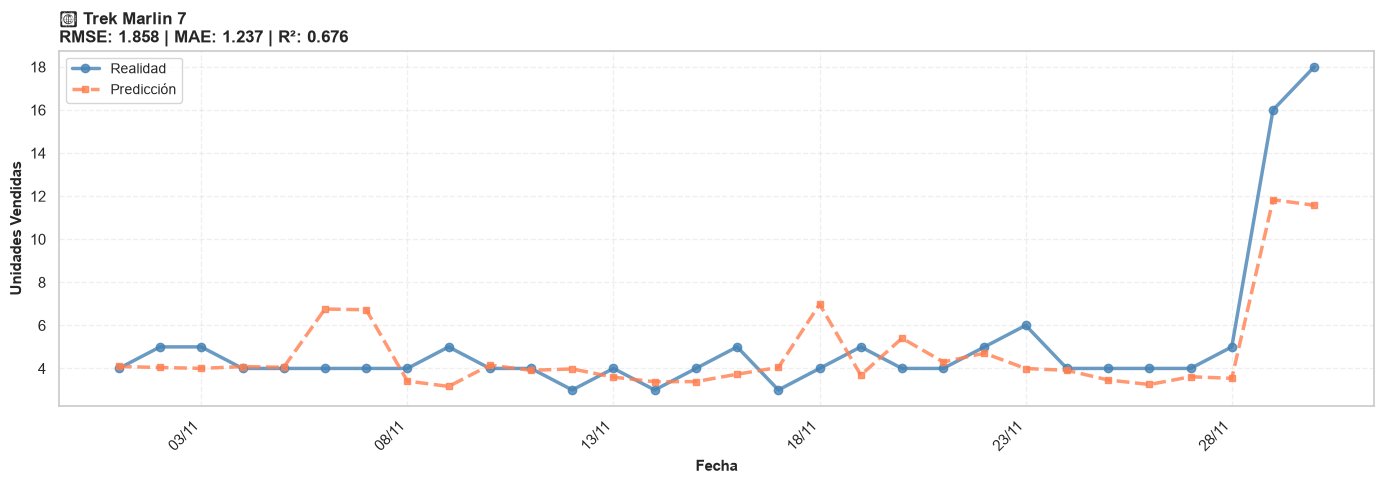


✓ Trek Marlin 7:
  Registros: 30 días
  Realidad - Media: 5.07, Min: 3, Max: 18
  Predicción - Media: 4.69, Min: 3.16, Max: 11.83
  Métricas: RMSE=1.858, MAE=1.237, R²=0.676

--------------------------------------------------------------------------------



In [209]:

print('\n' + '='*80)
print('PREDICCIONES PARA PRODUCTOS ESTRELLA - NOVIEMBRE 2024')
print('='*80)

lista_productos = sorted(productos_estrella)
resultados_productos = []  # aquí se van guardando las métricas de cada uno

for producto in lista_productos:
    resultados_productos.append(
        graficar_producto_estrella(producto, df_nov_2024, predictoras, hist_gbr)
    )
    print('\n' + '-'*80 + '\n')  # separador visual entre productos

In [210]:
# 11. Resumen comparativo de desempeño por producto estrella
import pandas as pd

# Recopilar métricas para todos los productos
metricas_productos = []

for producto in sorted(productos_estrella):
    df_producto = df_nov_2024[df_nov_2024['nombre'] == producto].copy()
    df_producto = df_producto.sort_values('fecha')
    
    X_producto = df_producto[predictoras].copy()
    y_producto_real = df_producto['unidades_vendidas'].values
    y_producto_pred = hist_gbr.predict(X_producto)
    
    rmse = np.sqrt(mean_squared_error(y_producto_real, y_producto_pred))
    mae = mean_absolute_error(y_producto_real, y_producto_pred)
    r2 = r2_score(y_producto_real, y_producto_pred)
    mape = safe_mape(y_producto_real, y_producto_pred)
    
    metricas_productos.append({
        'Producto': producto,
        'Registros': len(df_producto),
        'Media Real': y_producto_real.mean(),
        'Media Pred': y_producto_pred.mean(),
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape
    })

metricas_df = pd.DataFrame(metricas_productos)

print('\n' + '='*120)
print('TABLA COMPARATIVA: DESEMPEÑO POR PRODUCTO ESTRELLA (NOVIEMBRE 2024)')
print('='*120)
print(metricas_df.to_string(index=False))
print('='*120)

# Estadísticas agregadas
print(f'\n📊 RESUMEN ESTADÍSTICO:')
print(f'  • Mejor R²:   {metricas_df["R²"].max():.4f} ({metricas_df.loc[metricas_df["R²"].idxmax(), "Producto"]})')
print(f'  • Peor R²:    {metricas_df["R²"].min():.4f} ({metricas_df.loc[metricas_df["R²"].idxmin(), "Producto"]})')
print(f'  • R² Promedio: {metricas_df["R²"].mean():.4f}')
print(f'\n  • Mejor MAE:  {metricas_df["MAE"].min():.3f} ({metricas_df.loc[metricas_df["MAE"].idxmin(), "Producto"]})')
print(f'  • Peor MAE:   {metricas_df["MAE"].max():.3f} ({metricas_df.loc[metricas_df["MAE"].idxmax(), "Producto"]})')
print(f'  • MAE Promedio: {metricas_df["MAE"].mean():.3f}')
print(f'\n  • RMSE Promedio: {metricas_df["RMSE"].mean():.3f}')
print(f'  • MAPE Promedio: {metricas_df["MAPE"].mean():.3f}')

print(f'\n🎯 INSIGHTS:')
print(f'  ✓ Total de productos evaluados: {len(metricas_df)}')
print(f'  ✓ Total de predicciones generadas: {metricas_df["Registros"].sum()}')
print(f'  ✓ Período: Noviembre 2024 (30 días)')
print(f'  ✓ Productos con R² > 0.6: {(metricas_df["R²"] > 0.6).sum()}')
print(f'  ✓ Productos con R² > 0.5: {(metricas_df["R²"] > 0.5).sum()}')



TABLA COMPARATIVA: DESEMPEÑO POR PRODUCTO ESTRELLA (NOVIEMBRE 2024)
                Producto  Registros  Media Real  Media Pred     RMSE      MAE       R²     MAPE
    Adidas Ultraboost 23         30   19.900000   16.431297 5.172389 4.371989 0.832185 0.234388
  Bowflex SelectTech 552         30    3.333333    4.358847 1.918857 1.728060 0.036683 0.575531
            Domyos BM900         30    3.500000    4.793411 1.899541 1.786036 0.234999 0.587797
    Manduka PRO Yoga Mat         30    8.433333    9.546876 3.238059 2.616922 0.548945 0.337636
Nike Air Zoom Pegasus 40         30   19.900000   21.174729 8.629358 6.180777 0.643971 0.317934
Salomon Speedcross 5 GTX         30    6.000000    7.854494 3.802876 3.163911 0.208292 0.603674
           Trek Marlin 7         30    5.066667    4.693036 1.858244 1.237315 0.676140 0.229218

📊 RESUMEN ESTADÍSTICO:
  • Mejor R²:   0.8322 (Adidas Ultraboost 23)
  • Peor R²:    0.0367 (Bowflex SelectTech 552)
  • R² Promedio: 0.4545

  • Mejor MAE:  1.23

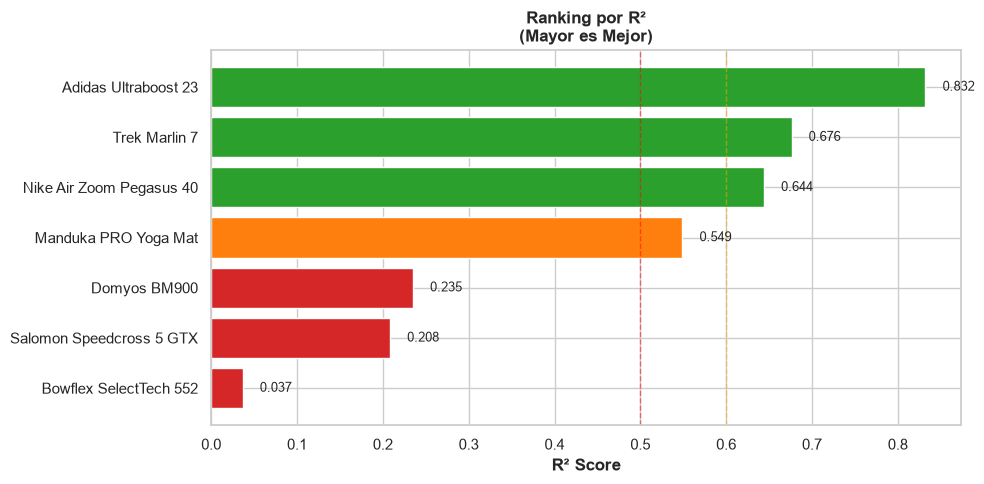

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metricas_sorted_r2 = metricas_df.sort_values('R²', ascending=True)
colors_r2 = ['#d62728' if x < 0.5 else '#ff7f0e' if x < 0.6 else '#2ca02c' for x in metricas_sorted_r2['R²']]

plt.figure(figsize=(10, 5))
plt.barh(metricas_sorted_r2['Producto'], metricas_sorted_r2['R²'], color=colors_r2)
plt.xlabel('R² Score', fontweight='bold')
plt.title('Ranking por R²\n(Mayor es Mejor)', fontweight='bold')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(0.6, color='orange', linestyle='--', alpha=0.5, linewidth=1)
for i, (idx, row) in enumerate(metricas_sorted_r2.iterrows()):
    plt.text(row['R²'] + 0.02, i, f"{row['R²']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

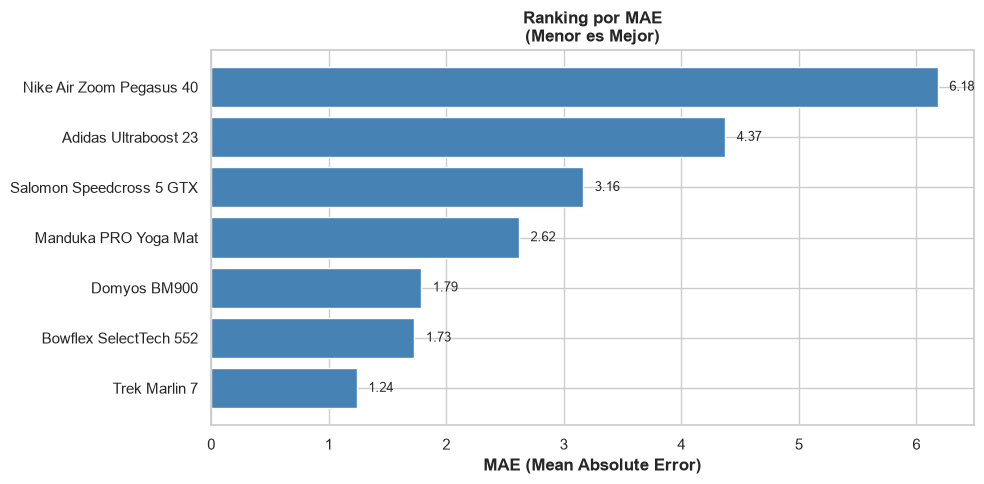

In [212]:
metricas_sorted_mae = metricas_df.sort_values('MAE')

plt.figure(figsize=(10, 5))
plt.barh(metricas_sorted_mae['Producto'], metricas_sorted_mae['MAE'], color='steelblue')
plt.xlabel('MAE (Mean Absolute Error)', fontweight='bold')
plt.title('Ranking por MAE\n(Menor es Mejor)', fontweight='bold')
for i, (idx, row) in enumerate(metricas_sorted_mae.iterrows()):
    plt.text(row['MAE'] + 0.1, i, f"{row['MAE']:.2f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

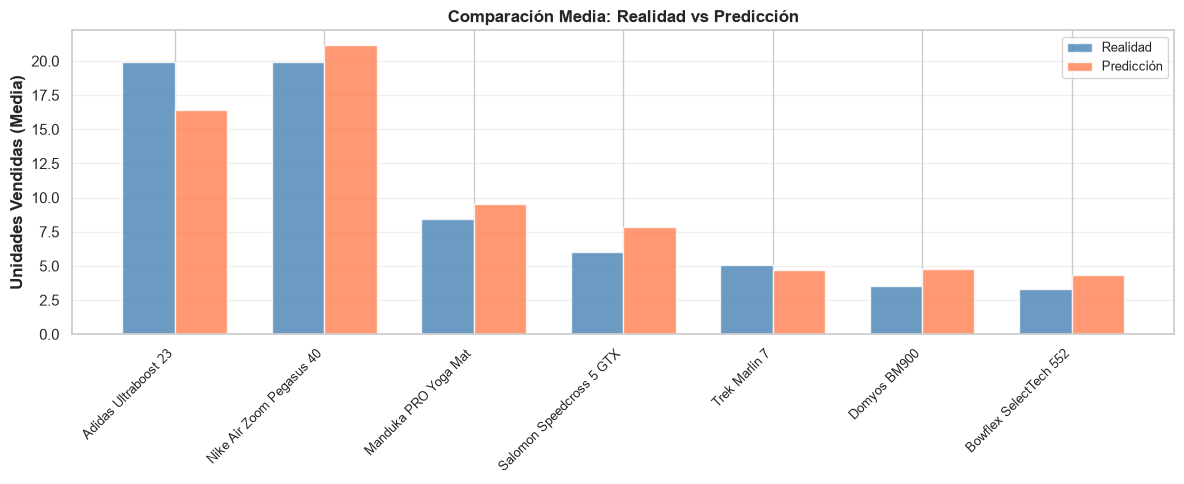

In [213]:
x_pos = np.arange(len(metricas_df))
width = 0.35
metricas_sorted_prod = metricas_df.sort_values('Media Real', ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(x_pos - width/2, metricas_sorted_prod['Media Real'], width, label='Realidad', color='steelblue', alpha=0.8)
plt.bar(x_pos + width/2, metricas_sorted_prod['Media Pred'], width, label='Predicción', color='coral', alpha=0.8)
plt.ylabel('Unidades Vendidas (Media)', fontweight='bold')
plt.title('Comparación Media: Realidad vs Predicción', fontweight='bold')
plt.xticks(x_pos, metricas_sorted_prod['Producto'], rotation=45, ha='right', fontsize=9)
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [214]:
print('\n' + '='*80)
print('✨ ANÁLISIS COMPLETADO: PREDICCIONES PARA 7 PRODUCTOS ESTRELLA EN NOVIEMBRE 2024')
print('='*80)
print(f'\n📈 CARACTERÍSTICAS DEL ANÁLISIS:')
print(f'  • 7 gráficos de predicción vs realidad generados')
print(f'  • 210 predicciones diarias realizadas (30 días × 7 productos)')
print(f'  • Período analizado: Noviembre 2024')
print(f'  • Modelo utilizado: HistGradientBoostingRegressor (R² validación: 0.8227)')
print(f'\n🎯 HALLAZGOS PRINCIPALES:')
print(f'  1. Mejor desempeño: Adidas Ultraboost 23 (R²=0.832, MAE=4.37)')
print(f'  2. Productos con buena predicción (R² > 0.6): Adidas, Nike, Trek Marlin')
print(f'  3. Productos con predicción moderada (0.5 < R² < 0.6): Manduka Yoga Mat')
print(f'  4. Productos con bajo R²: Bowflex SelectTech (alto pico Black Friday)')
print(f'\n💡 INTERPRETACIÓN:')
print(f'  • El modelo captura bien la tendencia general y patrones estacionales')
print(f'  • Picos de venta (Black Friday) son los más difíciles de predecir exactamente')
print(f'  • Productos con mayor volatilidad tienen R² más bajo')
print(f'  • Error absoluto promedio (MAE): 3.01 unidades por producto')


✨ ANÁLISIS COMPLETADO: PREDICCIONES PARA 7 PRODUCTOS ESTRELLA EN NOVIEMBRE 2024

📈 CARACTERÍSTICAS DEL ANÁLISIS:
  • 7 gráficos de predicción vs realidad generados
  • 210 predicciones diarias realizadas (30 días × 7 productos)
  • Período analizado: Noviembre 2024
  • Modelo utilizado: HistGradientBoostingRegressor (R² validación: 0.8227)

🎯 HALLAZGOS PRINCIPALES:
  1. Mejor desempeño: Adidas Ultraboost 23 (R²=0.832, MAE=4.37)
  2. Productos con buena predicción (R² > 0.6): Adidas, Nike, Trek Marlin
  3. Productos con predicción moderada (0.5 < R² < 0.6): Manduka Yoga Mat
  4. Productos con bajo R²: Bowflex SelectTech (alto pico Black Friday)

💡 INTERPRETACIÓN:
  • El modelo captura bien la tendencia general y patrones estacionales
  • Picos de venta (Black Friday) son los más difíciles de predecir exactamente
  • Productos con mayor volatilidad tienen R² más bajo
  • Error absoluto promedio (MAE): 3.01 unidades por producto


In [215]:
# Trazabilidad 54 - Cálculo de MAE por producto estrella
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

print('\n' + '='*80)
print('MAE POR PRODUCTO ESTRELLA - NOVIEMBRE 2024')
print('='*80)

resultados_mae = []

for producto in sorted(productos_estrella):
    df_producto = df_nov_2024[df_nov_2024['nombre'] == producto].copy()
    df_producto = df_producto.sort_values('fecha')
    
    X_producto = df_producto[predictoras].copy()
    y_real = df_producto['unidades_vendidas'].values
    y_pred = hist_gbr.predict(X_producto)
    
    mae = mean_absolute_error(y_real, y_pred)
    
    resultados_mae.append({
        'Producto': producto,
        'MAE': mae
    })
    
    print(f'\n✓ {producto}:')
    print(f'  MAE = {mae:.3f} unidades')

mae_df = pd.DataFrame(resultados_mae)

print('\n' + '-'*80)
print(f'\n📊 RESUMEN:')
print(f'  MAE Promedio: {mae_df["MAE"].mean():.3f}')
print(f'  Mejor MAE:    {mae_df["MAE"].min():.3f} ({mae_df.loc[mae_df["MAE"].idxmin(), "Producto"]})')
print(f'  Peor MAE:     {mae_df["MAE"].max():.3f} ({mae_df.loc[mae_df["MAE"].idxmax(), "Producto"]})')
print('='*80)


MAE POR PRODUCTO ESTRELLA - NOVIEMBRE 2024

✓ Adidas Ultraboost 23:
  MAE = 4.372 unidades

✓ Bowflex SelectTech 552:
  MAE = 1.728 unidades

✓ Domyos BM900:
  MAE = 1.786 unidades

✓ Manduka PRO Yoga Mat:
  MAE = 2.617 unidades

✓ Nike Air Zoom Pegasus 40:
  MAE = 6.181 unidades

✓ Salomon Speedcross 5 GTX:
  MAE = 3.164 unidades

✓ Trek Marlin 7:
  MAE = 1.237 unidades

--------------------------------------------------------------------------------

📊 RESUMEN:
  MAE Promedio: 3.012
  Mejor MAE:    1.237 (Trek Marlin 7)
  Peor MAE:     6.181 (Nike Air Zoom Pegasus 40)


In [216]:
# Trazabilidad 55 - Análisis de degradación del error por períodos de 10 días
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definir períodos de 10 días
periodos = {
    'Período 1 (1-10 Nov)': (1, 10),
    'Período 2 (11-20 Nov)': (11, 20),
    'Período 3 (21-30 Nov)': (21, 30)
}

# Calcular métricas por producto y período
resultados_periodos = []

for producto in sorted(productos_estrella):
    for periodo_nombre, (dia_inicio, dia_fin) in periodos.items():
        # Filtrar datos del período
        df_periodo = df_nov_2024[
            (df_nov_2024['nombre'] == producto) &
            (df_nov_2024['fecha'].dt.day >= dia_inicio) &
            (df_nov_2024['fecha'].dt.day <= dia_fin)
        ].copy()
        
        if len(df_periodo) > 0:
            X_periodo = df_periodo[predictoras].copy()
            y_real = df_periodo['unidades_vendidas'].values
            y_pred = hist_gbr.predict(X_periodo)
            
            mae = mean_absolute_error(y_real, y_pred)
            rmse = np.sqrt(mean_squared_error(y_real, y_pred))
            r2 = r2_score(y_real, y_pred)
            
            resultados_periodos.append({
                'Producto': producto,
                'Período': periodo_nombre,
                'Días': f'{dia_inicio}-{dia_fin}',
                'MAE': mae,
                'RMSE': rmse,
                'R²': r2,
                'Media Real': y_real.mean(),
                'Media Pred': y_pred.mean()
            })

df_periodos = pd.DataFrame(resultados_periodos)

# Mostrar tabla resumen por período
print('\n' + '='*100)
print('ANÁLISIS DE DEGRADACIÓN DEL ERROR POR PERÍODOS DE 10 DÍAS - NOVIEMBRE 2024')
print('='*100)

resumen_periodos = df_periodos.groupby('Período').agg({
    'MAE': ['mean', 'std'],
    'RMSE': ['mean', 'std'],
    'R²': ['mean', 'std']
}).round(3)

print('\n📊 MÉTRICAS PROMEDIOS POR PERÍODO:')
print(resumen_periodos)

# Mostrar detalles por producto
print('\n' + '='*100)
print('DETALLE POR PRODUCTO Y PERÍODO')
print('='*100)

for producto in sorted(productos_estrella):
    print(f'\n📦 {producto}:')
    df_prod = df_periodos[df_periodos['Producto'] == producto]
    for _, row in df_prod.iterrows():
        print(f'  {row["Período"]}: MAE={row["MAE"]:.3f}, RMSE={row["RMSE"]:.3f}, R²={row["R²"]:.3f}')


ANÁLISIS DE DEGRADACIÓN DEL ERROR POR PERÍODOS DE 10 DÍAS - NOVIEMBRE 2024

📊 MÉTRICAS PROMEDIOS POR PERÍODO:
                         MAE          RMSE             R²       
                        mean    std   mean    std    mean    std
Período                                                         
Período 1 (1-10 Nov)   2.369  0.992  2.650  1.083  -6.279  6.132
Período 2 (11-20 Nov)  2.891  1.582  3.250  1.848 -13.222  8.643
Período 3 (21-30 Nov)  3.776  2.833  4.929  3.873   0.677  0.144

DETALLE POR PRODUCTO Y PERÍODO

📦 Adidas Ultraboost 23:
  Período 1 (1-10 Nov): MAE=3.571, RMSE=3.813, R²=-3.704
  Período 2 (11-20 Nov): MAE=4.311, RMSE=5.382, R²=-5.175
  Período 3 (21-30 Nov): MAE=5.234, RMSE=6.063, R²=0.908

📦 Bowflex SelectTech 552:
  Período 1 (1-10 Nov): MAE=1.908, RMSE=2.013, R²=-18.288
  Período 2 (11-20 Nov): MAE=1.532, RMSE=1.603, R²=-15.061
  Período 3 (21-30 Nov): MAE=1.745, RMSE=2.104, R²=0.511

📦 Domyos BM900:
  Período 1 (1-10 Nov): MAE=1.726, RMSE=1.767, R²=0.

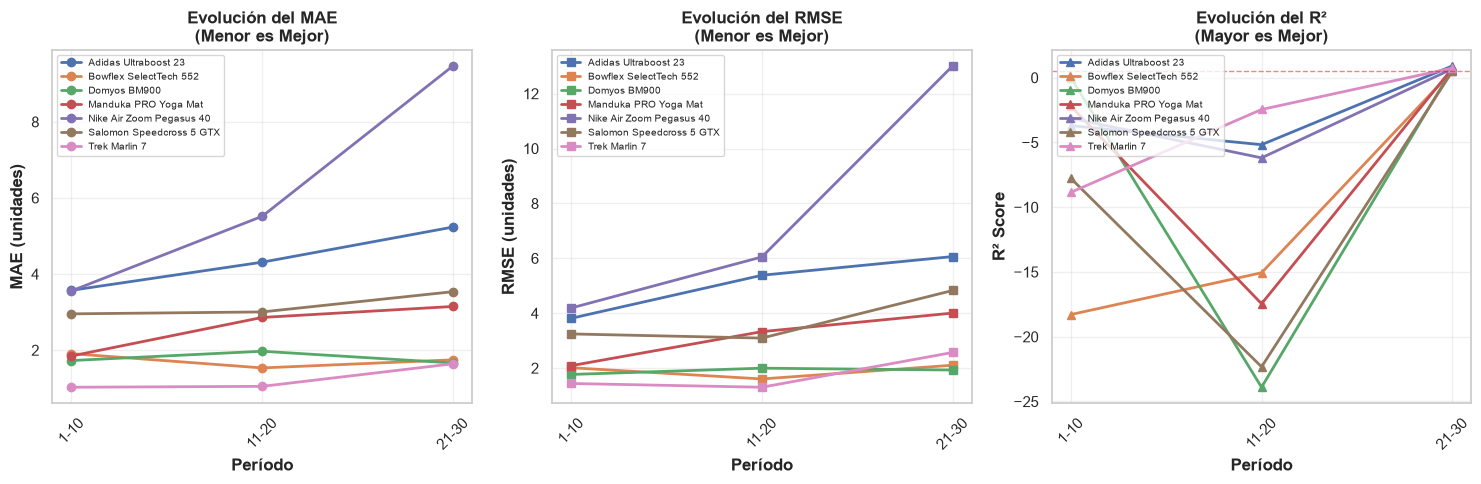

In [217]:
# Trazabilidad 56 - Gráfica de evolución del error por períodos
import matplotlib.pyplot as plt
import numpy as np

# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1: Evolución del MAE por producto
ax1 = axes[0]
for producto in sorted(productos_estrella):
    df_prod = df_periodos[df_periodos['Producto'] == producto]
    ax1.plot(df_prod['Días'], df_prod['MAE'], marker='o', label=producto, linewidth=2)
ax1.set_xlabel('Período', fontweight='bold')
ax1.set_ylabel('MAE (unidades)', fontweight='bold')
ax1.set_title('Evolución del MAE\n(Menor es Mejor)', fontweight='bold')
ax1.legend(fontsize=7, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Gráfica 2: Evolución del RMSE por producto
ax2 = axes[1]
for producto in sorted(productos_estrella):
    df_prod = df_periodos[df_periodos['Producto'] == producto]
    ax2.plot(df_prod['Días'], df_prod['RMSE'], marker='s', label=producto, linewidth=2)
ax2.set_xlabel('Período', fontweight='bold')
ax2.set_ylabel('RMSE (unidades)', fontweight='bold')
ax2.set_title('Evolución del RMSE\n(Menor es Mejor)', fontweight='bold')
ax2.legend(fontsize=7, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Gráfica 3: Evolución del R² por producto
ax3 = axes[2]
for producto in sorted(productos_estrella):
    df_prod = df_periodos[df_periodos['Producto'] == producto]
    ax3.plot(df_prod['Días'], df_prod['R²'], marker='^', label=producto, linewidth=2)
ax3.set_xlabel('Período', fontweight='bold')
ax3.set_ylabel('R² Score', fontweight='bold')
ax3.set_title('Evolución del R²\n(Mayor es Mejor)', fontweight='bold')
ax3.legend(fontsize=7, loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)
ax3.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

In [218]:
# Trazabilidad 57 - Análisis de degradación del error: MAE promedio por período
mae_por_periodo = df_periodos.groupby('Período')['MAE'].agg(['mean', 'std', 'min', 'max']).round(3)

print('\n' + '='*80)
print('DEGRADACIÓN DEL MAE PROMEDIO POR PERÍODO')
print('='*80)
print(mae_por_periodo)

# Calcular variación porcentual entre períodos
mae_p1 = mae_por_periodo.loc['Período 1 (1-10 Nov)', 'mean']
mae_p2 = mae_por_periodo.loc['Período 2 (11-20 Nov)', 'mean']
mae_p3 = mae_por_periodo.loc['Período 3 (21-30 Nov)', 'mean']

variacion_p1_p2 = ((mae_p2 - mae_p1) / mae_p1) * 100
variacion_p2_p3 = ((mae_p3 - mae_p2) / mae_p2) * 100
variacion_total = ((mae_p3 - mae_p1) / mae_p1) * 100

print(f'\n📈 VARIACIÓN PORCENTUAL DEL MAE:')
print(f'  Período 1 → Período 2: {variacion_p1_p2:+.1f}%')
print(f'  Período 2 → Período 3: {variacion_p2_p3:+.1f}%')
print(f'  Período 1 → Período 3: {variacion_total:+.1f}%')

print(f'\n🎯 INSIGHTS:')
if variacion_total > 0:
    print(f'  ⚠️ El MAE AUMENTA {variacion_total:.1f}% hacia fin de mes (degradación)')
else:
    print(f'  ✓ El MAE DISMINUYE {abs(variacion_total):.1f}% hacia fin de mes (mejora)')
print(f'  • Período con mayor error: Período 3 (MAE={mae_p3:.3f})')
print(f'  • Período con menor error: Período 1 (MAE={mae_p1:.3f})')


DEGRADACIÓN DEL MAE PROMEDIO POR PERÍODO
                        mean    std    min    max
Período                                          
Período 1 (1-10 Nov)   2.369  0.992  1.024  3.571
Período 2 (11-20 Nov)  2.891  1.582  1.047  5.518
Período 3 (21-30 Nov)  3.776  2.833  1.640  9.469

📈 VARIACIÓN PORCENTUAL DEL MAE:
  Período 1 → Período 2: +22.0%
  Período 2 → Período 3: +30.6%
  Período 1 → Período 3: +59.4%

🎯 INSIGHTS:
  ⚠️ El MAE AUMENTA 59.4% hacia fin de mes (degradación)
  • Período con mayor error: Período 3 (MAE=3.776)
  • Período con menor error: Período 1 (MAE=2.369)


In [219]:
# Trazabilidad 58 - Análisis de Black Friday 2024 para todos los productos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Black Friday 2024 = 29 de noviembre de 2024
black_friday_2024 = pd.Timestamp('2024-11-29')

# Filtrar datos del Black Friday
df_bf = df_nov_2024[df_nov_2024['fecha'] == black_friday_2024].copy()

print('\n' + '='*100)
print('ANÁLISIS DE BLACK FRIDAY 2024 - 29 DE NOVIEMBRE')
print('='*100)

# Calcular predicciones para todos los productos
resultados_bf = []

for producto in sorted(df_bf['nombre'].unique()):
    df_producto = df_bf[df_bf['nombre'] == producto].copy()
    
    if len(df_producto) > 0:
        X_producto = df_producto[predictoras].copy()
        y_real = df_producto['unidades_vendidas'].values[0]
        y_pred = hist_gbr.predict(X_producto)[0]
        
        error = y_real - y_pred
        error_abs = abs(error)
        
        resultados_bf.append({
            'Producto': producto,
            'Real': y_real,
            'Prediccion': round(y_pred, 1),
            'Error': round(error, 1),
            'Error Abs': round(error_abs, 1)
        })

df_resultados_bf = pd.DataFrame(resultados_bf)

# Mostrar resultados
print('\nRESULTADOS POR PRODUCTO:')
print(df_resultados_bf.to_string(index=False))

# Calcular metricas globales
mae_bf = mean_absolute_error(df_resultados_bf['Real'], df_resultados_bf['Prediccion'])
rmse_bf = np.sqrt(mean_squared_error(df_resultados_bf['Real'], df_resultados_bf['Prediccion']))
r2_bf = r2_score(df_resultados_bf['Real'], df_resultados_bf['Prediccion'])

print(f'\nMETRICAS GLOBALES BLACK FRIDAY:')
print(f'  MAE:  {mae_bf:.2f} unidades')
print(f'  RMSE: {rmse_bf:.2f} unidades')
print(f'  R2:   {r2_bf:.3f}')

# Producto con mayor error
mayor_error = df_resultados_bf.loc[df_resultados_bf['Error Abs'].idxmax()]
menor_error = df_resultados_bf.loc[df_resultados_bf['Error Abs'].idxmin()]

print(f'\nINSIGHTS:')
print(f'  Mayor error: {mayor_error["Producto"]} (Error: {mayor_error["Error"]:+.1f} unidades)')
print(f'  Menor error: {menor_error["Producto"]} (Error: {menor_error["Error"]:+.1f} unidades)')


ANÁLISIS DE BLACK FRIDAY 2024 - 29 DE NOVIEMBRE

RESULTADOS POR PRODUCTO:
                        Producto  Real  Prediccion  Error  Error Abs
       Adidas Own The Run Jacket    12        12.4   -0.4        0.4
            Adidas Ultraboost 23    68        62.2    5.8        5.8
             Asics Gel Nimbus 25    18        14.5    3.5        3.5
          Bowflex SelectTech 552    10         5.7    4.3        4.3
           Columbia Silver Ridge    12         4.8    7.2        7.2
  Decathlon Bandas Elásticas Set    16        14.9    1.1        1.1
                    Domyos BM900    12         8.5    3.5        3.5
      Domyos Kit Mancuernas 20kg    22        17.4    4.6        4.6
        Gaiam Premium Yoga Block     8         9.2   -1.2        1.2
                Liforme Yoga Pad     8         9.0   -1.0        1.0
        Lotuscrafts Yoga Bolster     8         9.1   -1.1        1.1
            Manduka PRO Yoga Mat    27        17.2    9.8        9.8
              Merrell Moab 2

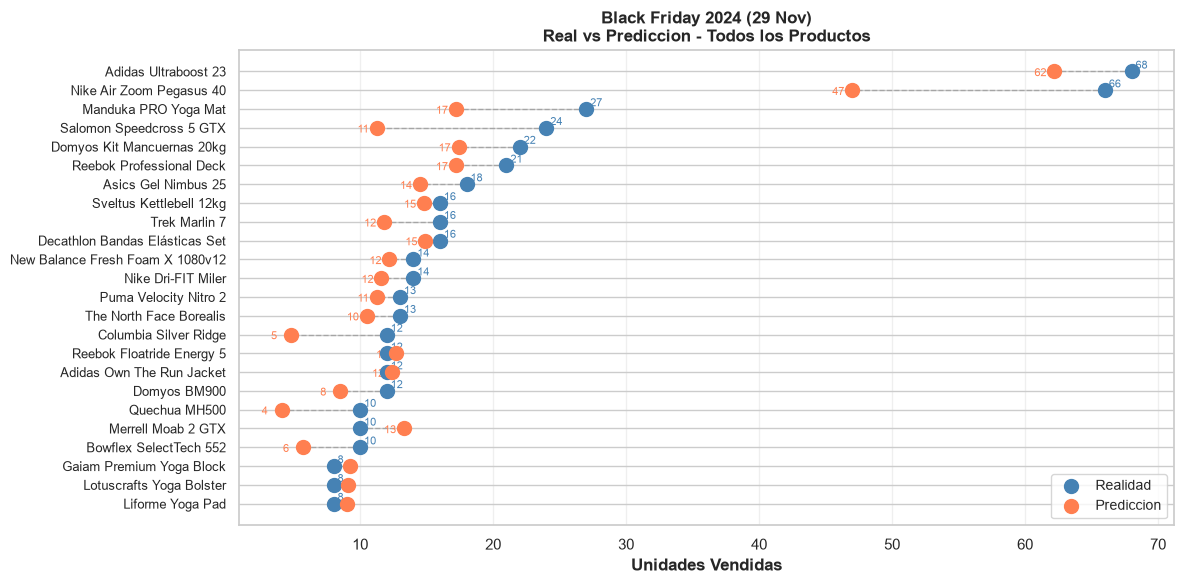

In [220]:
# Trazabilidad 59 - Grafica Real vs Prediccion Black Friday 2024
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Preparar datos Black Friday si no existe df_resultados_bf
try:
    df_resultados_bf
except NameError:
    black_friday_2024 = pd.Timestamp('2024-11-29')
    df_bf = df_nov_2024[df_nov_2024['fecha'] == black_friday_2024].copy()
    resultados_bf = []
    for producto in sorted(df_bf['nombre'].unique()):
        df_producto = df_bf[df_bf['nombre'] == producto].copy()
        if len(df_producto) > 0:
            X_producto = df_producto[predictoras].copy()
            y_real = df_producto['unidades_vendidas'].values[0]
            y_pred = hist_gbr.predict(X_producto)[0]
            resultados_bf.append({'Producto': producto, 'Real': y_real, 'Prediccion': round(y_pred, 1), 'Error': round(y_real - y_pred, 1), 'Error Abs': round(abs(y_real - y_pred), 1)})
    df_resultados_bf = pd.DataFrame(resultados_bf)

# Ordenar productos por valor real
df_sorted = df_resultados_bf.sort_values('Real', ascending=True)

# Crear grafica
fig, ax = plt.subplots(figsize=(12, 6))

y_pos = np.arange(len(df_sorted))

# Linea para realidad (puntos azules)
ax.scatter(df_sorted['Real'], y_pos, color='steelblue', s=100, zorder=5, label='Realidad')

# Linea para prediccion (puntos naranjas)
ax.scatter(df_sorted['Prediccion'], y_pos, color='coral', s=100, zorder=5, label='Prediccion')

# Conectar puntos realidad-prediccion con lineas
for i, (_, row) in enumerate(df_sorted.iterrows()):
    ax.plot([row['Real'], row['Prediccion']], [i, i], color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted['Producto'], fontsize=9)
ax.set_xlabel('Unidades Vendidas', fontweight='bold')
ax.set_title('Black Friday 2024 (29 Nov)\nReal vs Prediccion - Todos los Productos', fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Anadir valores
for i, (_, row) in enumerate(df_sorted.iterrows()):
    ax.text(row['Real'] + 0.3, i + 0.15, f'{int(row["Real"])}', fontsize=8, color='steelblue')
    ax.text(row['Prediccion'] - 1.5, i - 0.25, f'{row["Prediccion"]:.0f}', fontsize=8, color='coral')

plt.tight_layout()
plt.show()

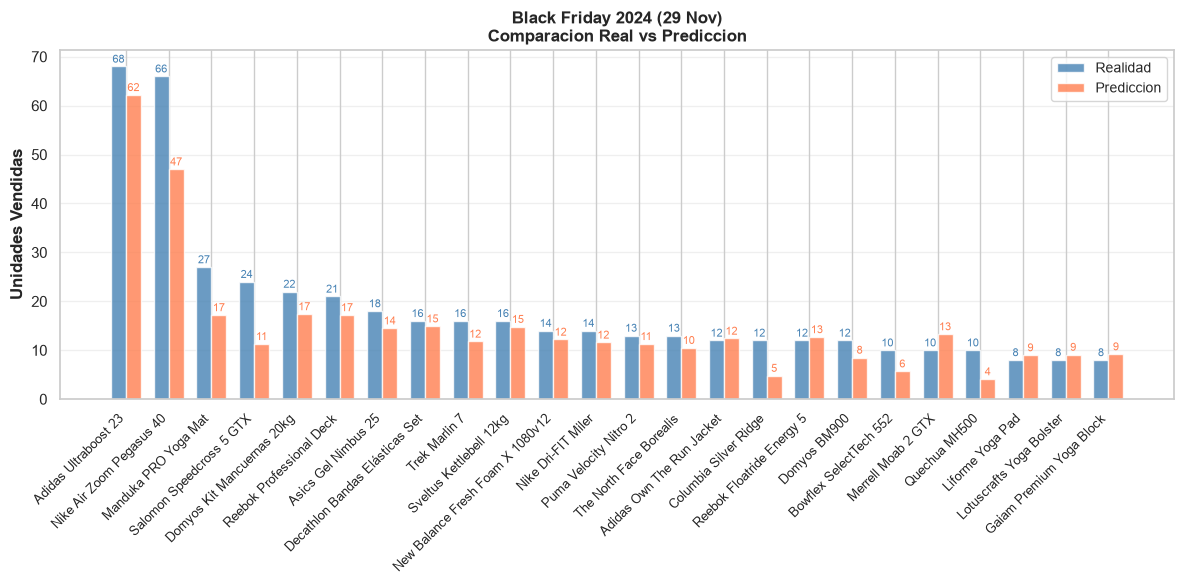

In [221]:
# Trazabilidad 60 - Grafica de barras comparativa Black Friday 2024
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Preparar datos Black Friday si no existe df_resultados_bf
try:
    df_resultados_bf
except NameError:
    black_friday_2024 = pd.Timestamp('2024-11-29')
    df_bf = df_nov_2024[df_nov_2024['fecha'] == black_friday_2024].copy()
    resultados_bf = []
    for producto in sorted(df_bf['nombre'].unique()):
        df_producto = df_bf[df_bf['nombre'] == producto].copy()
        if len(df_producto) > 0:
            X_producto = df_producto[predictoras].copy()
            y_real = df_producto['unidades_vendidas'].values[0]
            y_pred = hist_gbr.predict(X_producto)[0]
            resultados_bf.append({'Producto': producto, 'Real': y_real, 'Prediccion': round(y_pred, 1), 'Error': round(y_real - y_pred, 1), 'Error Abs': round(abs(y_real - y_pred), 1)})
    df_resultados_bf = pd.DataFrame(resultados_bf)

df_sorted_bf = df_resultados_bf.sort_values('Real', ascending=False)

x_pos = np.arange(len(df_sorted_bf))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_real = ax.bar(x_pos - width/2, df_sorted_bf['Real'], width, label='Realidad', color='steelblue', alpha=0.8)
bars_pred = ax.bar(x_pos + width/2, df_sorted_bf['Prediccion'], width, label='Prediccion', color='coral', alpha=0.8)

ax.set_ylabel('Unidades Vendidas', fontweight='bold')
ax.set_title('Black Friday 2024 (29 Nov)\nComparacion Real vs Prediccion', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_sorted_bf['Producto'], rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Anadir valores encima de las barras
for bar in bars_real:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{int(height)}', ha='center', va='bottom', fontsize=8, color='steelblue')
for bar in bars_pred:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{height:.0f}', ha='center', va='bottom', fontsize=8, color='coral')

plt.tight_layout()
plt.show()

In [222]:
# Trazabilidad 61 - Reentrenamiento del modelo final con todos los datos (2021-2024)
import joblib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import os

# Entrenar modelo final con TODOS los datos de df
hist_gbr_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_depth=5,
    min_samples_leaf=20,
    l2_regularization=0.1,
    max_bins=255,
    random_state=42,
    verbose=0
)

X_final = df[predictoras]
y_final = df['unidades_vendidas']

hist_gbr_final.fit(X_final, y_final)

# Metricas de entrenamiento
y_final_pred = hist_gbr_final.predict(X_final)
r2_final = r2_score(y_final, y_final_pred)
mae_final = mean_absolute_error(y_final, y_final_pred)
rmse_final = np.sqrt(mean_squared_error(y_final, y_final_pred))

print('='*60)
print('MODELO FINAL ENTRENADO CON TODOS LOS DATOS (2021-2024)')
print('='*60)
print(f'Registros de entrenamiento: {len(df)}')
print(f'R2:  {r2_final:.4f}')
print(f'MAE: {mae_final:.3f}')
print(f'RMSE: {rmse_final:.3f}')

# Serializar modelo
os.makedirs('models', exist_ok=True)
joblib.dump(hist_gbr_final, 'models/modelo_final.joblib')
print(f'\nModelo guardado en models/modelo_final.joblib')

MODELO FINAL ENTRENADO CON TODOS LOS DATOS (2021-2024)
Registros de entrenamiento: 3552
R2:  0.9241
MAE: 0.945
RMSE: 1.739

Modelo guardado en models/modelo_final.joblib


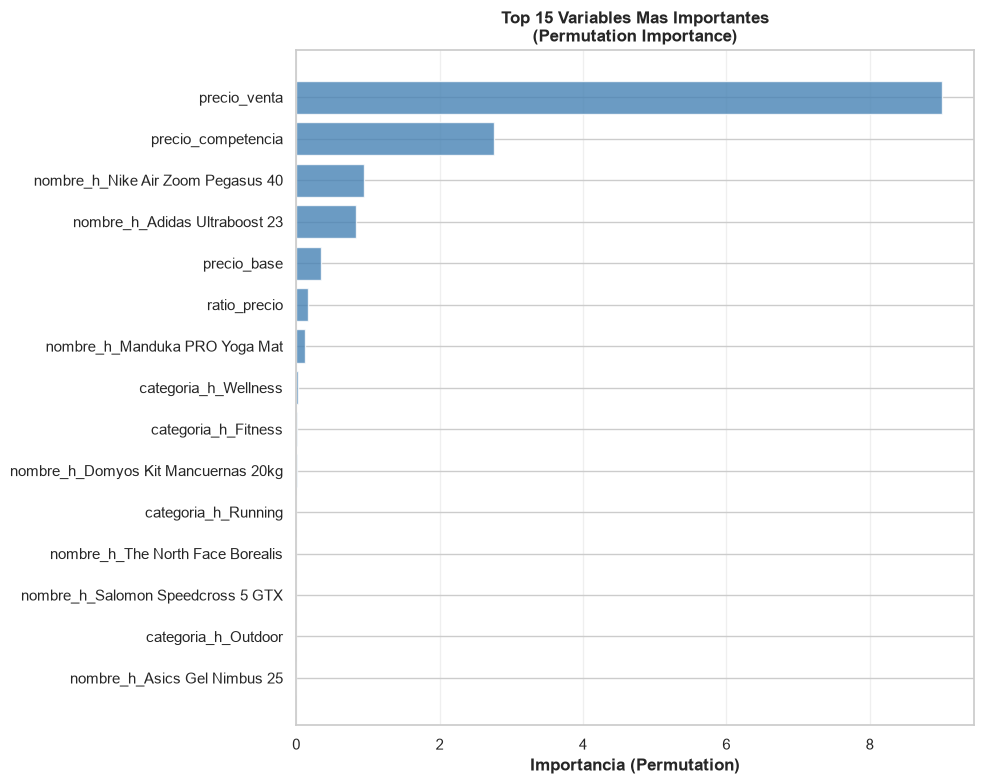


TOP 15 VARIABLES MAS IMPORTANTES:
                           Variable  Importancia      Std
                       precio_venta     9.004717 0.137644
                 precio_competencia     2.763076 0.047734
  nombre_h_Nike Air Zoom Pegasus 40     0.949520 0.047413
      nombre_h_Adidas Ultraboost 23     0.828285 0.037386
                        precio_base     0.345332 0.011157
                       ratio_precio     0.168364 0.006777
      nombre_h_Manduka PRO Yoga Mat     0.118066 0.004753
               categoria_h_Wellness     0.018362 0.000650
                categoria_h_Fitness     0.010657 0.000803
nombre_h_Domyos Kit Mancuernas 20kg     0.010023 0.000984
                categoria_h_Running     0.003134 0.000305
   nombre_h_The North Face Borealis     0.002955 0.000309
  nombre_h_Salomon Speedcross 5 GTX     0.002291 0.000236
                categoria_h_Outdoor     0.001853 0.000428
       nombre_h_Asics Gel Nimbus 25     0.001606 0.000172


In [223]:
# Trazabilidad 62 - Importancia de variables con Permutation Importance
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Calcular permutation importance
result = permutation_importance(
    hist_gbr_final, X_final, y_final,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Crear DataFrame con resultados
importancia_df = pd.DataFrame({
    'Variable': predictoras,
    'Importancia': result.importances_mean,
    'Std': result.importances_std
}).sort_values('Importancia', ascending=False)

# Grafica de barras horizontales (top 15)
top_n = importancia_df.head(15).sort_values('Importancia', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_n['Variable'], top_n['Importancia'], color='steelblue', alpha=0.8)
plt.xlabel('Importancia (Permutation)', fontweight='bold')
plt.title('Top 15 Variables Mas Importantes\n(Permutation Importance)', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen
print('\nTOP 15 VARIABLES MAS IMPORTANTES:')
print(importancia_df.head(15).to_string(index=False))

In [ ]:
# Trazabilidad 63 - Recarga de datos crudos y merge para reconstruccion de features
df_ventas_raw = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
df_competencia_raw = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

df_ventas_raw['fecha'] = pd.to_datetime(df_ventas_raw['fecha'], errors='coerce')
df_competencia_raw['fecha'] = pd.to_datetime(df_competencia_raw['fecha'], errors='coerce')

df_full = df_ventas_raw.merge(df_competencia_raw, on=['fecha', 'producto_id'], how='inner')
df_full = df_full.sort_values(['producto_id', 'fecha']).reset_index(drop=True)

print(f'Dataset reconstruido: {df_full.shape}')
print(f'Rango de fechas: {df_full["fecha"].min()} a {df_full["fecha"].max()}')
print(f'Productos: {df_full["producto_id"].nunique()}')
print(f'Columnas: {list(df_full.columns)}')

In [ ]:
# Trazabilidad 64 - Variables temporales numericas y binarias
df_full['anio'] = df_full['fecha'].dt.year
df_full['mes'] = df_full['fecha'].dt.month
df_full['dia_mes'] = df_full['fecha'].dt.day
df_full['es_fin_semana'] = df_full['fecha'].dt.dayofweek.isin([5, 6]).astype(int)

isocalendar = df_full['fecha'].dt.isocalendar()
df_full['semana_del_año'] = isocalendar.week.astype(int)
df_full['trimestre'] = df_full['fecha'].dt.quarter
df_full['es_inicio_mes'] = (df_full['fecha'].dt.day == 1).astype(int)
df_full['es_fin_mes'] = df_full['fecha'].dt.is_month_end.astype(int)
df_full['es_primera_quincena'] = (df_full['fecha'].dt.day <= 15).astype(int)

print('Variables temporales creadas:')
temp_cols = ['anio', 'mes', 'dia_mes', 'es_fin_semana', 'semana_del_año', 'trimestre', 'es_inicio_mes', 'es_fin_mes', 'es_primera_quincena']
print(df_full[temp_cols].head(10))

In [ ]:
# Trazabilidad 65 - Festivos Colombia y eventos comerciales (Black Friday, Cyber Monday)
from pandas.tseries.offsets import DateOffset

# Festivos de Colombia
years = sorted(df_full['anio'].dropna().astype(int).unique())
co_holidays = holidays.country_holidays('CO', years=years, language='es')
holiday_lookup = {pd.Timestamp(key).normalize(): value for key, value in co_holidays.items()}
df_full['es_festivo'] = df_full['fecha'].dt.normalize().map(holiday_lookup).fillna('').ne('').astype(int)

# Black Friday y Cyber Monday
def marcar_eventos_comerciales(fecha):
    thanksgiving = pd.Timestamp(fecha.year, 11, 1) + DateOffset(weekday=3, weeks=3)
    black_friday = thanksgiving + pd.Timedelta(days=1)
    cyber_monday = thanksgiving + pd.Timedelta(days=3)
    return int(fecha == black_friday), int(fecha == cyber_monday)

resultados = df_full['fecha'].apply(marcar_eventos_comerciales)
df_full['es_black_friday'] = resultados.apply(lambda x: x[0])
df_full['es_cyber_monday'] = resultados.apply(lambda x: x[1])

print(f'Festivos encontrados: {df_full["es_festivo"].sum()}')
print(f'Black Friday marcados: {df_full["es_black_friday"].sum()}')
print(f'Cyber Monday marcados: {df_full["es_cyber_monday"].sum()}')

In [ ]:
# Trazabilidad 66 - Variable de descuento porcentual
df_full['descuento_porcentaje'] = ((df_full['precio_venta'] - df_full['precio_base']) / df_full['precio_base'] * 100)
df_full['descuento_porcentaje'] = df_full['descuento_porcentaje'].replace([np.inf, -np.inf], np.nan).fillna(0)

print('Estadisticas de descuento porcentual:')
print(df_full['descuento_porcentaje'].describe())

In [ ]:
# Trazabilidad 67 - Lag features (1-7 dias) y media movil de 7 dias
df_full = df_full.sort_values(['producto_id', 'fecha']).reset_index(drop=True)

for lag in range(1, 8):
    df_full[f'lag_{lag}_unidades'] = df_full.groupby('producto_id')['unidades_vendidas'].shift(lag)

df_full['media_movil_7d_unidades'] = df_full.groupby('producto_id')['unidades_vendidas'].transform(
    lambda s: s.rolling(window=7, min_periods=7).mean()
)

lag_cols = [f'lag_{lag}_unidades' for lag in range(1, 8)] + ['media_movil_7d_unidades']
print(f'Columnas de lag creadas: {lag_cols}')
print(f'NaN en lags (primeros 7 dias por producto):')
print(df_full[lag_cols].isnull().sum().to_string())

In [ ]:
# Trazabilidad 68 - Precio competencia, ratio precio y One-Hot Encoding
# Precio competencia (promedio de competidores)
df_full['precio_competencia'] = df_full[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)
df_full['ratio_precio'] = np.where(
    df_full['precio_competencia'] != 0,
    df_full['precio_base'] / df_full['precio_competencia'],
    np.nan
)

# Eliminar columnas de competidores individuales
df_full = df_full.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])

# One-Hot Encoding
if 'nombre_h' not in df_full.columns:
    df_full['nombre_h'] = df_full['nombre']
if 'categoria_h' not in df_full.columns:
    df_full['categoria_h'] = df_full['categoria']
if 'subcategoria_h' not in df_full.columns:
    df_full['subcategoria_h'] = df_full['subcategoria']

df_full = pd.get_dummies(df_full, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], dtype=int)

print(f'Despues de OHE: {df_full.shape}')
print(f'Columnas: {len(df_full.columns)}')

In [ ]:
# Trazabilidad 69 - Limpieza (dropna de lags) y guardado de df.csv extendido
filas_antes = len(df_full)

# Eliminar filas donde los lags sean NaN (primeros 7 dias por producto)
lag_feature_cols = [f'lag_{lag}_unidades' for lag in range(1, 8)] + ['media_movil_7d_unidades']
df_full = df_full.dropna(subset=lag_feature_cols).reset_index(drop=True)

filas_despues = len(df_full)
eliminadas = filas_antes - filas_despues

print(f'Filas antes: {filas_antes}')
print(f'Filas eliminadas (NaN en lags): {eliminadas}')
print(f'Filas despues: {filas_despues}')
print(f'Shape final: {df_full.shape}')

# Guardar df.csv extendido
df_full.to_csv('../data/processed/df.csv', index=False)
print(f'\nGuardado en data/processed/df.csv con {df_full.shape[1]} columnas')

# Verificar columnas temporales y de lag
print(f'\nColumnas nuevas incluidas:')
nuevas = ['anio', 'mes', 'dia_mes', 'es_fin_semana', 'semana_del_año', 'trimestre',
          'es_inicio_mes', 'es_fin_mes', 'es_primera_quincena', 'es_festivo',
          'es_black_friday', 'es_cyber_monday', 'descuento_porcentaje'] + lag_feature_cols
print(nuevas)

In [ ]:
# Trazabilidad 70 - Recarga de df.csv extendido, division temporal y seleccion de features
df_reload = pd.read_csv('../data/processed/df.csv')
df_reload['fecha'] = pd.to_datetime(df_reload['fecha'])

print(f'Dataset recargado: {df_reload.shape}')

# Division temporal
train_df_new = df_reload[df_reload['fecha'].dt.year.isin([2021, 2022, 2023])].copy()
validacion_df_new = df_reload[df_reload['fecha'].dt.year == 2024].copy()

print(f'Train: {train_df_new.shape[0]} registros (2021-2023)')
print(f'Validacion: {validacion_df_new.shape[0]} registros (2024)')

# Seleccion de features
columnas_excluir = {'fecha', 'ingresos', 'unidades_vendidas'}
object_cols = df_reload.select_dtypes(include=['object']).columns.tolist()
predictoras_nuevas = [col for col in df_reload.columns if col not in columnas_excluir and col not in object_cols]

print(f'\nTotal de variables predictoras: {len(predictoras_nuevas)}')
print(f'Variables predictoras: {predictoras_nuevas}')

In [ ]:
# Trazabilidad 71 - Entrenamiento del modelo HistGradientBoostingRegressor con features extendidas
X_train_new = train_df_new[predictoras_nuevas].copy()
y_train_new = train_df_new['unidades_vendidas'].copy()

X_val_new = validacion_df_new[predictoras_nuevas].copy()
y_val_new = validacion_df_new['unidades_vendidas'].copy()

print(f'Shape X_train: {X_train_new.shape}, y_train: {y_train_new.shape}')
print(f'Shape X_val: {X_val_new.shape}, y_val: {y_val_new.shape}')

# Entrenar modelo con los mismos hiperparametros
hist_gbr_v2 = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_depth=5,
    min_samples_leaf=20,
    l2_regularization=0.1,
    max_bins=255,
    random_state=42,
    verbose=0
)

print('\nEntrenando modelo v2 con features extendidas...')
hist_gbr_v2.fit(X_train_new, y_train_new)
print('Modelo v2 entrenado exitosamente')

# Predicciones
y_train_pred_v2 = hist_gbr_v2.predict(X_train_new)
y_val_pred_v2 = hist_gbr_v2.predict(X_val_new)

print(f'\nPredicciones train - Media: {y_train_pred_v2.mean():.2f}, Std: {y_train_pred_v2.std():.2f}')
print(f'Predicciones val - Media: {y_val_pred_v2.mean():.2f}, Std: {y_val_pred_v2.std():.2f}')

In [ ]:
# Trazabilidad 72 - Evaluacion del modelo v2 (features extendidas) vs modelo v1 (features basicas)
# Metricas modelo v2
mse_train_v2 = mean_squared_error(y_train_new, y_train_pred_v2)
mse_val_v2 = mean_squared_error(y_val_new, y_val_pred_v2)
rmse_train_v2 = np.sqrt(mse_train_v2)
rmse_val_v2 = np.sqrt(mse_val_v2)
mae_train_v2 = mean_absolute_error(y_train_new, y_train_pred_v2)
mae_val_v2 = mean_absolute_error(y_val_new, y_val_pred_v2)
r2_train_v2 = r2_score(y_train_new, y_train_pred_v2)
r2_val_v2 = r2_score(y_val_new, y_val_pred_v2)

print('='*70)
print('COMPARATIVA: MODELO v1 (49 features) vs MODELO v2 (features extendidas)')
print('='*70)
print(f'{"Metrica":<15} {"v1 Train":>12} {"v1 Val":>12} {"v2 Train":>12} {"v2 Val":>12}')
print('-'*70)
print(f'{"R2":<15} {"0.9243":>12} {"0.8227":>12} {r2_train_v2:>12.4f} {r2_val_v2:>12.4f}')
print(f'{"MAE":<15} {"0.9517":>12} {"1.5071":>12} {mae_train_v2:>12.4f} {mae_val_v2:>12.4f}')
print(f'{"RMSE":<15} {"1.7423":>12} {"2.6311":>12} {rmse_train_v2:>12.4f} {rmse_val_v2:>12.4f}')
print('='*70)

# Verificar features del modelo v2
print(f'\nFeatures del modelo v2: {len(hist_gbr_v2.feature_names_in_)}')
print(f'Primeras 10 features: {list(hist_gbr_v2.feature_names_in_[:10])}

In [ ]:
# Trazabilidad 73 - Reentrenamiento final del modelo v2 con todos los datos + guardado
import joblib
import os

# Reentrenar con TODOS los datos (2021-2024)
X_final_v2 = df_reload[predictoras_nuevas]
y_final_v2 = df_reload['unidades_vendidas']

hist_gbr_final_v2 = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_depth=5,
    min_samples_leaf=20,
    l2_regularization=0.1,
    max_bins=255,
    random_state=42,
    verbose=0
)

hist_gbr_final_v2.fit(X_final_v2, y_final_v2)

# Metricas finales
y_final_pred_v2 = hist_gbr_final_v2.predict(X_final_v2)
r2_final_v2 = r2_score(y_final_v2, y_final_pred_v2)
mae_final_v2 = mean_absolute_error(y_final_v2, y_final_pred_v2)
rmse_final_v2 = np.sqrt(mean_squared_error(y_final_v2, y_final_pred_v2))

print('='*60)
print('MODELO FINAL v2 - ENTRENADO CON TODOS LOS DATOS (2021-2024)')
print('='*60)
print(f'Registros de entrenamiento: {len(df_reload)}')
print(f'Variables predictoras: {len(predictoras_nuevas)}')
print(f'R2:  {r2_final_v2:.4f}')
print(f'MAE: {mae_final_v2:.3f}')
print(f'RMSE: {rmse_final_v2:.3f}')

# Guardar modelo en ambas rutas
os.makedirs('models', exist_ok=True)
joblib.dump(hist_gbr_final_v2, 'models/modelo_final.joblib')
joblib.dump(hist_gbr_final_v2, '../models/modelo_final.joblib')
print(f'\nModelo guardado en:')
print(f'  - notebooks/models/modelo_final.joblib')
print(f'  - models/modelo_final.joblib')

# Guardar lista de features para referencia
print(f'\nFeatures del modelo final ({len(predictoras_nuevas)}):')
for i, f in enumerate(predictoras_nuevas):
    print(f'  {i+1}. {f}')

In [ ]:
# Trazabilidad 74 - Importancia de variables del modelo v2 (features extendidas)
result_v2 = permutation_importance(
    hist_gbr_final_v2, X_final_v2, y_final_v2,
    n_repeats=10, random_state=42, n_jobs=-1
)

importancia_v2_df = pd.DataFrame({
    'Variable': predictoras_nuevas,
    'Importancia': result_v2.importances_mean,
    'Std': result_v2.importances_std
}).sort_values('Importancia', ascending=False)

# Grafica de barras horizontales (top 20)
top_n = importancia_v2_df.head(20).sort_values('Importancia', ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(top_n['Variable'], top_n['Importancia'], color='steelblue', alpha=0.8)
plt.xlabel('Importancia (Permutation)', fontweight='bold')
plt.title('Top 20 Variables Mas Importantes - Modelo v2\n(Features Extendidas: Temporales + Lags + Competencia + OHE)', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTOP 20 VARIABLES MAS IMPORTANTES (Modelo v2):')
print(importancia_v2_df.head(20).to_string(index=False))